# Typologie fonctionnelle des gares européennes par profil réseau

**MSPR B3 : clustering non supervisé (graph analytics + KMeans/GMM/HDBSCAN)**

## Question métier (ObRail Europe)
Quelles familles de gares structurent le maillage ferroviaire européen (hubs internationaux,
portes d'entrée du réseau de nuit, gares de corridor, nœuds régionaux maillés) et où ancrer
de nouvelles liaisons de nuit ?

## Données
- `mart.dim_station` (PostgreSQL, seed du 2026-03-07) : 24 135 gares (`is_airport = FALSE`)
- `mart.dim_route_train` : 62 972 tronçons gare→gare consécutifs (trips GTFS + Back on Track)

**Unité d'analyse : la gare** (nœud du graphe), pas le trip ni le tronçon.

## Démarche (CRISP-DM)
1. Extraction depuis le data mart PostgreSQL
2. Nettoyage (symétrisation, tronçons aberrants, correction des pays par reverse geocoding)
3. Feature engineering réseau (networkx : degré, betweenness, clustering local…)
4. EDA et sélection de variables
5. Clustering KMeans (principal), GMM et HDBSCAN (challengers), scénarios de préparation
6. Validation par stabilité, interprétation métier, contrôle des biais, livrables

> Notebook autonome : tout le code est défini ici, aucune dépendance à un fichier `.py`.
> L'inférence en production depuis le modèle sauvegardé est dans [`inference.py`](inference.py).

In [1]:
from __future__ import annotations

import io
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import psycopg2
import reverse_geocode
from sklearn.cluster import HDBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler

from IPython.display import Image, display

# Force l'UTF-8 sur la console Windows (sans effet sous Jupyter)
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")

In [2]:
DB = dict(
    host=os.environ.get("DB_HOST", "localhost"),
    port=int(os.environ.get("DB_PORT", "5433")),
    dbname=os.environ.get("DB_NAME", "postgres"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD", "lpironti"),
)
# Dossier de sortie, robuste au répertoire d'exécution du notebook
OUT = Path("clustering/output") if Path("clustering").is_dir() else Path("output")
SEED = 42

MIN_SEGMENT_KM = 0.5          # en dessous : doublons de quais
MAX_SEGMENT_KM_STATS = 500.0  # au-dessus : artefacts de distance, exclus des stats
BTW_PIVOTS = 1000             # pivots pour la betweenness approximée
BTW_LOG_SCALE = 1e9           # échelle du log de la betweenness
K_RANGE = range(2, 10)
SIL_SAMPLE = 10_000           # taille d'échantillon pour la silhouette

# Features utilisées pour le clustering. share_night et share_cross_border
# sont exclues (trop peu de gares concernées) et servent juste au profilage.
CLUSTER_FEATURES = ["deg_log", "btw_log", "pagerank_log", "clustering_coef",
                    "dist_median_log", "dist_p90_log"]
SPEARMAN_DROP_THRESHOLD = 0.9

# Paires trop corrélées qu'on garde quand même, avec la raison.
KEEP_BOTH = {
    frozenset({"dist_median_log", "dist_p90_log"}):
        "médiane = espacement typique des arrêts, p90 = liaisons longues des hubs",
}

DEFAULT_K = 5

# Noms des clusters pour k=5 / seed=42 — mis à jour d'après la heatmap des profils.
# C0 : degree +2.39σ, dist_p90 +1.15σ  → Hub
# C1 : tout ~0, n=11 084               → Nœud régional (cluster de base)
# C2 : clustering_coef +0.91σ          → Gare contournée
# C3 : clustering_coef +3.03σ          → Maillon urbain (réseau local très dense)
# C4 : dist légèrement long            → Corridor interurbain
CLUSTER_NAMES: dict[int, str] = {
    0: "Hub structurant / porte nocturne",
    1: "Nœud régional maillé",
    2: "Gare contournée par les directs",
    3: "Maillon urbain/périurbain",
    4: "Gare de corridor interurbain",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
OUT.mkdir(parents=True, exist_ok=True)

# Le calcul des features prend ~3 min ; on recharge le cache s'il existe.
USE_CACHE = True


### Fonctions du pipeline

Toute la logique est définie ci-dessous. Les sections suivantes appellent ces fonctions
étape par étape.

In [3]:
def extract() -> tuple[pd.DataFrame, pd.DataFrame]:
    conn = psycopg2.connect(**DB)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*SQLAlchemy.*")
        stations = pd.read_sql(
            """SELECT station_id, station_name, city, country_code,
                      latitude::float AS lat, longitude::float AS lon
               FROM mart.dim_station WHERE is_airport = FALSE""",
            conn,
        )
        edges = pd.read_sql(
            """SELECT dep_station_id, arr_station_id,
                      distance_km::float AS distance_km, is_night_train
               FROM mart.dim_route_train""",
            conn,
        )
    conn.close()
    print(f"[extract] {len(stations)} gares, {len(edges)} tronçons orientés")
    return stations, edges

def fix_country_codes(stations: pd.DataFrame) -> pd.DataFrame:
    """Corrige les country_code hérités du pays du feed GTFS (ex. gares NL
    codées AT/DE/BE dans le dump) par reverse geocoding offline sur lat/lon."""
    coords = list(zip(stations["lat"], stations["lon"]))
    geo = reverse_geocode.search(coords)
    stations = stations.copy()
    stations["country_geo"] = [g["country_code"] for g in geo]
    changed = (stations["country_geo"] != stations["country_code"]).sum()
    print(f"[clean] reverse geocoding : {changed} country_code corrigés "
          f"({changed / len(stations):.1%})")
    return stations

def build_undirected_edges(edges: pd.DataFrame, stations: pd.DataFrame) -> pd.DataFrame:
    """Symétrise les tronçons (A→B et B→A = même infrastructure), supprime les
    résidus < 0.5 km, et enrichit avec les pays corrigés des deux extrémités."""
    e = edges.copy()
    n0 = len(e)
    e = e[e["distance_km"] >= MIN_SEGMENT_KM]
    print(f"[clean] tronçons < {MIN_SEGMENT_KM} km supprimés : {n0 - len(e)}")

    u = np.minimum(e["dep_station_id"], e["arr_station_id"])
    v = np.maximum(e["dep_station_id"], e["arr_station_id"])
    e = e.assign(u=u, v=v)
    e = e[e["u"] != e["v"]]
    und = (
        e.groupby(["u", "v"], as_index=False)
        .agg(distance_km=("distance_km", "mean"), is_night=("is_night_train", "max"))
    )
    print(f"[clean] {len(und)} tronçons non orientés "
          f"(dédup de {len(e)} orientés)")

    cc = stations.set_index("station_id")["country_geo"]
    und["country_u"] = und["u"].map(cc)
    und["country_v"] = und["v"].map(cc)
    und["is_cross_border"] = (und["country_u"] != und["country_v"]).astype(int)
    und["is_long_artefact"] = (und["distance_km"] > MAX_SEGMENT_KM_STATS).astype(int)
    print(f"[clean] arêtes transfrontalières : {und['is_cross_border'].sum()} "
          f"({und['is_cross_border'].mean():.1%}) ; "
          f"> {MAX_SEGMENT_KM_STATS:.0f} km (exclues des stats de distance) : "
          f"{und['is_long_artefact'].sum()}")
    return und

In [4]:
def compute_features(und: pd.DataFrame, stations: pd.DataFrame) -> pd.DataFrame:
    G = nx.Graph()
    G.add_weighted_edges_from(und[["u", "v", "distance_km"]].itertuples(index=False, name=None))
    print(f"[graph] {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

    components = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = components[0]
    print(f"[graph] {len(components)} composantes connexes ; "
          f"géante = {len(giant)} nœuds ({len(giant) / G.number_of_nodes():.1%})")

    # Centralités sur le graphe non pondéré (la distance ne sert qu'aux distances par gare)
    degree = dict(G.degree())
    pagerank = nx.pagerank(G, alpha=0.85, weight=None)
    clustering_coef = nx.clustering(G)
    # Betweenness approximée (1000 pivots) sur tout le graphe
    k = min(BTW_PIVOTS, G.number_of_nodes())
    print(f"[graph] betweenness approximée (k={k} pivots)…")
    btw = nx.betweenness_centrality(G, k=k, normalized=True, seed=SEED)

    # Stats des arêtes de chaque gare (ses deux extrémités)
    half = pd.concat([
        und.rename(columns={"u": "node"})[["node", "distance_km", "is_night",
                                           "is_cross_border", "is_long_artefact"]],
        und.rename(columns={"v": "node"})[["node", "distance_km", "is_night",
                                           "is_cross_border", "is_long_artefact"]],
    ], ignore_index=True)
    shares = half.groupby("node").agg(
        share_night=("is_night", "mean"),
        share_cross_border=("is_cross_border", "mean"),
    )
    dist_ok = half[half["is_long_artefact"] == 0]
    dist_stats = dist_ok.groupby("node")["distance_km"].agg(
        dist_median="median", dist_p90=lambda s: s.quantile(0.9)
    )

    feats = stations.set_index("station_id").join(shares, how="inner")
    feats = feats.join(dist_stats, how="left")
    # Gares dont toutes les arêtes font plus de 500 km : on garde la distance brute
    missing = feats["dist_median"].isna()
    if missing.any():
        fallback = half.groupby("node")["distance_km"].agg(
            dist_median="median", dist_p90=lambda s: s.quantile(0.9))
        feats.loc[missing, ["dist_median", "dist_p90"]] = fallback.loc[
            feats.index[missing], ["dist_median", "dist_p90"]].values
        print(f"[features] {missing.sum()} gares avec uniquement des arêtes "
              f"> {MAX_SEGMENT_KM_STATS:.0f} km : fallback distance brute")

    feats["degree"] = feats.index.map(degree)
    feats["pagerank"] = feats.index.map(pagerank)
    feats["clustering_coef"] = feats.index.map(clustering_coef)
    feats["betweenness"] = feats.index.map(btw)
    feats["in_giant"] = feats.index.isin(giant).astype(int)

    # log : les distributions sont très étalées (lois de puissance)
    feats["deg_log"] = np.log1p(feats["degree"])
    feats["btw_log"] = np.log1p(feats["betweenness"] * BTW_LOG_SCALE)
    feats["pagerank_log"] = np.log1p(feats["pagerank"] * 1e6)
    feats["dist_median_log"] = np.log1p(feats["dist_median"])
    feats["dist_p90_log"] = np.log1p(feats["dist_p90"])

    feats = feats.reset_index()
    print(f"[features] matrice : {len(feats)} gares × "
          f"{len(CLUSTER_FEATURES)} features candidates")
    return feats

In [5]:
def eda_and_select(feats: pd.DataFrame) -> list[str]:
    raw_cols = ["degree", "betweenness", "pagerank", "clustering_coef",
                "dist_median", "dist_p90", "share_cross_border", "share_night"]
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, col in zip(axes.flat, raw_cols):
        ax.hist(feats[col].dropna(), bins=60, color="#2b6cb0")
        ax.set_yscale("log")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("nombre de gares (log)")
    fig.suptitle("Analyse univariée des distributions brutes (axe y log)")
    fig.tight_layout()
    fig.savefig(OUT / "eda_distributions.png", dpi=120)
    plt.close(fig)

    # Comparaison avant / après transformation log
    pairs = [("degree", "deg_log"), ("betweenness", "btw_log"),
             ("dist_median", "dist_median_log")]
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for j, (raw, log) in enumerate(pairs):
        axes[0, j].hist(feats[raw].dropna(), bins=60, color="#c53030")
        axes[0, j].set_title(f"{raw} (brut)")
        axes[1, j].hist(feats[log].dropna(), bins=60, color="#2f855a")
        axes[1, j].set_title(f"{log} (transformé)")
    fig.suptitle("Transformation log : avant et après")
    fig.tight_layout()
    fig.savefig(OUT / "eda_transformations.png", dpi=120)
    plt.close(fig)

    # Boxplots des features transformées
    fig, ax = plt.subplots(figsize=(11, 5))
    cols_box = CLUSTER_FEATURES
    ax.boxplot([feats[c].dropna() for c in cols_box], tick_labels=cols_box)
    ax.set_title("Boxplots des features candidates (après transformation log)")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    fig.tight_layout()
    fig.savefig(OUT / "eda_boxplots.png", dpi=120)
    plt.close(fig)

    corr_cols = CLUSTER_FEATURES + ["share_cross_border", "share_night"]
    corr = feats[corr_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_cols)), corr_cols)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                    fontsize=8,
                    color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
    fig.colorbar(im)
    ax.set_title("Corrélations de Spearman des features candidates")
    fig.tight_layout()
    fig.savefig(OUT / "eda_correlation.png", dpi=120)
    plt.close(fig)

    # On retire une feature de chaque paire trop corrélée (|Spearman| > seuil),
    # sauf les exceptions justifiées dans KEEP_BOTH.
    selected = list(CLUSTER_FEATURES)
    sub = corr.loc[CLUSTER_FEATURES, CLUSTER_FEATURES]
    for i, a in enumerate(CLUSTER_FEATURES):
        for b in CLUSTER_FEATURES[i + 1:]:
            rho = sub.loc[a, b]
            if abs(rho) <= SPEARMAN_DROP_THRESHOLD:
                continue
            pair = frozenset({a, b})
            if pair in KEEP_BOTH:
                print(f"[selection] {a} / {b} : Spearman={rho:.3f} > "
                      f"{SPEARMAN_DROP_THRESHOLD}, gardées : {KEEP_BOTH[pair]}")
            elif b in selected:
                selected.remove(b)
                print(f"[selection] {b} retiré (Spearman avec {a} = {rho:.3f})")
    rho_pr = sub.loc["deg_log", "pagerank_log"]
    print(f"[selection] pagerank_log vs deg_log : Spearman = {rho_pr:.3f} "
          f"({'retiré' if 'pagerank_log' not in selected else 'conservé'})")
    print(f"[selection] features finales : {selected}")
    return selected

In [6]:
def run_clustering(feats: pd.DataFrame, selected: list[str], k_forced: int | None):
    X_raw = feats[selected].to_numpy()
    scaler = RobustScaler()
    X = scaler.fit_transform(X_raw)

    # Part de variance de chaque feature après mise à l'échelle
    var_share = X.var(axis=0) / X.var(axis=0).sum()
    variance_share = {f: round(float(v), 4) for f, v in zip(selected, var_share)}
    print(f"[scaling] part de variance post-scaling : {variance_share}")

    sils, inertias, bics = {}, {}, {}
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        inertias[k] = km.inertia_
        sils[k] = silhouette_score(X, km.labels_, sample_size=SIL_SAMPLE,
                                   random_state=SEED)
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              random_state=SEED).fit(X)
        bics[k] = gmm.bic(X)
        print(f"[kmeans] k={k} silhouette={sils[k]:.3f} inertie={inertias[k]:.0f} "
              f"BIC_GMM={bics[k]:.0f}")

    k_sil = max((k for k in K_RANGE), key=lambda k: sils[k])
    k_best = k_forced or DEFAULT_K

    # Normalisation [0,1] pour la vue superposée  (inertie et BIC : plus bas = mieux → on inverse)
    ks = list(K_RANGE)
    def _norm01(vals, invert=False):
        a = np.array(vals, dtype=float)
        r = (a - a.min()) / ((a.max() - a.min()) + 1e-12)
        return 1 - r if invert else r

    sil_n    = _norm01([sils[k]     for k in ks])
    inert_n  = _norm01([inertias[k] for k in ks], invert=True)
    bic_n    = _norm01([bics[k]     for k in ks], invert=True)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # — Silhouette individuelle —
    axes[0].plot(ks, [sils[k] for k in ks], "o-", color="#2b6cb0")
    axes[0].axvline(k_best, ls="--", color="gray", alpha=0.7, label=f"k retenu={k_best}")
    axes[0].axvline(k_sil,  ls=":",  color="red",  alpha=0.7, label=f"k silhouette max={k_sil}")
    axes[0].set_title("Silhouette (échantillon 10k)")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
    axes[0].legend(fontsize=7)

    # — Inertie (coude) —
    axes[1].plot(ks, [inertias[k] for k in ks], "o-", color="#c53030")
    axes[1].axvline(k_best, ls="--", color="gray", alpha=0.7, label=f"k retenu={k_best}")
    axes[1].set_title("Inertie (coude)")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("inertie")
    axes[1].legend(fontsize=7)

    # — BIC GMM —
    axes[2].plot(ks, [bics[k] for k in ks], "o-", color="#276749")
    axes[2].axvline(k_best, ls="--", color="gray", alpha=0.7, label=f"k retenu={k_best}")
    axes[2].set_title("BIC GMM (plus bas = mieux)")
    axes[2].set_xlabel("k"); axes[2].set_ylabel("BIC")
    axes[2].legend(fontsize=7)

    # — Vue superposée normalisée : tous les scores ensemble —
    axes[3].plot(ks, sil_n,   "o-",  color="#2b6cb0", lw=2, label="Silhouette (↑ mieux)")
    axes[3].plot(ks, inert_n, "s--", color="#c53030", lw=2, label="Inertie normalisée (↓→↑)")
    axes[3].plot(ks, bic_n,   "^:",  color="#276749", lw=2, label="BIC GMM normalisé (↓→↑)")
    axes[3].axvline(k_best, ls="--", color="gray", alpha=0.8, label=f"k retenu={k_best}")
    axes[3].axvline(k_sil,  ls=":",  color="red",  alpha=0.6, label=f"k sil. max={k_sil}")
    axes[3].set_title("Scores normalisés superposés ⟵ lire ici", fontweight="bold")
    axes[3].set_xlabel("k"); axes[3].set_ylabel("score normalisé [0-1]")
    axes[3].legend(fontsize=7)
    axes[3].set_ylim(-0.05, 1.05)

    fig.suptitle("Sélection du nombre de clusters k", fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUT / "kmeans_selection.png", dpi=120)
    plt.close(fig)

    print(f"[kmeans] k retenu = {k_best} (silhouette max à k={k_sil})")
    if k_best != len(CLUSTER_NAMES):
        CLUSTER_NAMES.clear()
    km = KMeans(n_clusters=k_best, n_init=10, random_state=SEED).fit(X)
    feats["cluster"] = km.labels_
    # Distance au centroïde, pour choisir des exemples typiques par cluster
    feats["dist_centroid"] = np.linalg.norm(
        X - km.cluster_centers_[km.labels_], axis=1)

    # Modèles concurrents
    gmm = GaussianMixture(n_components=k_best, covariance_type="full",
                          random_state=SEED).fit(X)
    feats["cluster_gmm"] = gmm.predict(X)
    hdb = HDBSCAN(min_cluster_size=250, min_samples=25, copy=True).fit(X)
    feats["cluster_hdbscan"] = hdb.labels_
    n_noise = int((hdb.labels_ == -1).sum())
    mask = hdb.labels_ != -1
    model_comparison = {
        "kmeans": {"n_clusters": int(k_best),
                   "silhouette": round(float(sils[k_best]), 3),
                   "pct_bruit": 0.0, "ari_vs_kmeans": 1.0},
        "gmm": {"n_clusters": int(k_best),
                "silhouette": round(float(silhouette_score(
                    X, feats["cluster_gmm"], sample_size=SIL_SAMPLE,
                    random_state=SEED)), 3),
                "pct_bruit": 0.0,
                "ari_vs_kmeans": round(float(adjusted_rand_score(
                    km.labels_, feats["cluster_gmm"])), 3)},
        "hdbscan": {"n_clusters": int(hdb.labels_.max() + 1),
                    "silhouette": round(float(silhouette_score(
                        X[mask], hdb.labels_[mask],
                        sample_size=min(SIL_SAMPLE, int(mask.sum())),
                        random_state=SEED)), 3),
                    "pct_bruit": round(n_noise / len(feats), 3),
                    "ari_vs_kmeans": round(float(adjusted_rand_score(
                        km.labels_[mask], hdb.labels_[mask])), 3)},
    }
    print(f"[modeles] comparaison : {json.dumps(model_comparison)}")

    # Silhouette par cluster, pour voir la séparation réelle
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X), size=min(SIL_SAMPLE, len(X)), replace=False)
    samp = silhouette_samples(X[idx], km.labels_[idx])
    sil_per_cluster = {
        int(c): {"mean": round(float(samp[km.labels_[idx] == c].mean()), 3),
                 "pct_negative": round(float((samp[km.labels_[idx] == c] < 0).mean()), 3)}
        for c in range(k_best)
    }
    print(f"[kmeans] silhouette par cluster : {sil_per_cluster}")

    metrics = {"silhouette": sils, "inertia": inertias, "bic_gmm": bics,
               "k_best": k_best, "k_max_silhouette": k_sil,
               "variance_share_post_scaling": variance_share,
               "model_comparison": model_comparison,
               "silhouette_per_cluster": sil_per_cluster}
    return feats, scaler, km, X, metrics


In [7]:
def stability_analysis(X: np.ndarray, labels: np.ndarray, k: int) -> dict:
    """Stabilité de la partition, l'équivalent de la validation croisée en non
    supervisé : on regarde si les clusters tiennent quand on change la seed et
    quand on ré-échantillonne les données."""
    seed_aris = [adjusted_rand_score(
        labels, KMeans(n_clusters=k, n_init=10, random_state=s).fit_predict(X))
        for s in range(10)]
    rng = np.random.default_rng(SEED)
    boot_aris = []
    for _ in range(20):
        idx = rng.choice(len(X), size=int(0.8 * len(X)), replace=False)
        lab = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X[idx])
        boot_aris.append(adjusted_rand_score(labels[idx], lab))
    stab = {
        "ari_multiseed_mean": round(float(np.mean(seed_aris)), 3),
        "ari_multiseed_min": round(float(np.min(seed_aris)), 3),
        "ari_bootstrap80_mean": round(float(np.mean(boot_aris)), 3),
        "ari_bootstrap80_min": round(float(np.min(boot_aris)), 3),
        "n_runs": {"multiseed": 10, "bootstrap": 20},
    }
    print(f"[stabilite] {stab}")
    return stab

def ablation(feats: pd.DataFrame, selected: list[str], k: int) -> dict:
    """Scénarios de préparation (sujet p.43). Piège : les scénarios dégénérés
    ont une meilleure silhouette (un gros cluster plus des micro-clusters
    d'outliers est trivialement bien séparé). Le vrai critère est la
    dégénérescence des tailles de clusters, pas la silhouette."""
    raw_map = {"deg_log": "degree", "btw_log": "betweenness",
               "pagerank_log": "pagerank", "clustering_coef": "clustering_coef",
               "dist_median_log": "dist_median", "dist_p90_log": "dist_p90"}
    raw_cols = [raw_map[c] for c in selected]
    scenarios = {
        "raw (sans log ni scaler)": feats[raw_cols].to_numpy(),
        "prepa1a : sans log + RobustScaler":
            RobustScaler().fit_transform(feats[raw_cols]),
        "prepa1b : log + StandardScaler":
            StandardScaler().fit_transform(feats[selected]),
        "prepa2 (retenu) : log + RobustScaler":
            RobustScaler().fit_transform(feats[selected]),
        "prepa2 sans pagerank":
            RobustScaler().fit_transform(
                feats[[c for c in selected if c != "pagerank_log"]]),
    }
    results = {}
    for name, X in scenarios.items():
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        sizes = sorted(np.bincount(km.labels_).tolist(), reverse=True)
        sil = silhouette_score(X, km.labels_, sample_size=SIL_SAMPLE,
                               random_state=SEED)
        degenerate = sizes[0] / len(feats) > 0.9
        results[name] = {"silhouette": round(float(sil), 3),
                         "tailles_clusters": sizes,
                         "degenere": bool(degenerate)}
        print(f"[ablation] {name}: silhouette={sil:.3f} tailles={sizes}"
              f"{' [DEGENERE]' if degenerate else ''}")
    return results

In [8]:
def interpret(feats: pd.DataFrame, selected: list[str], metrics: dict):
    profile_cols = ["degree", "betweenness", "clustering_coef", "dist_median",
                    "dist_p90", "share_cross_border", "share_night"]
    prof = feats.groupby("cluster").agg(
        n=("station_id", "size"),
        **{c: (c, "median") for c in profile_cols},
        pct_gares_nuit=("share_night", lambda s: (s > 0).mean()),
        pct_in_giant=("in_giant", "mean"),
    ).round(4)
    prof["nom"] = [CLUSTER_NAMES.get(c, f"cluster_{c}") for c in prof.index]

    # Exemples typiques = proches du centroïde. Les gares connues (fort degré)
    # sont les moins typiques, on les liste à part.
    typiques = (
        feats.sort_values("dist_centroid")
        .groupby("cluster")["station_name"].apply(lambda s: " | ".join(s.head(6)))
    )
    connus = (
        feats.sort_values("degree", ascending=False)
        .groupby("cluster")["station_name"].apply(lambda s: " | ".join(s.head(6)))
    )
    prof["exemples_typiques"] = typiques
    prof["membres_connus_top_degre"] = connus
    prof.to_csv(OUT / "cluster_profiles.csv")
    print("\n=== PROFILS DES CLUSTERS (médianes) ===")
    print(prof.drop(columns=["exemples_typiques", "membres_connus_top_degre"]).to_string())
    print("\n=== EXEMPLES TYPIQUES (proches du centroïde) ===")
    for c, ex in typiques.items():
        print(f"  cluster {c}: {ex}")
    print("\n=== GARES CONNUES (fort degré, atypiques) ===")
    for c, ex in connus.items():
        print(f"  cluster {c}: {ex}")

    # Heatmap des profils (médianes en z-scores)
    z = feats.groupby("cluster")[profile_cols].median()
    z = (z - feats[profile_cols].median()) / (feats[profile_cols].std() + 1e-12)
    fig, ax = plt.subplots(figsize=(10, 1.2 + 0.6 * len(z)))
    im = ax.imshow(z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(profile_cols)), profile_cols, rotation=30, ha="right")
    ax.set_yticks(range(len(z)),
                  [f"{c} ({CLUSTER_NAMES.get(c, '')}) n={prof.loc[c, 'n']}" for c in z.index])
    for i in range(len(z)):
        for j in range(len(profile_cols)):
            ax.text(j, i, f"{z.iloc[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(z.iloc[i, j]) > 1.2 else "black")
    fig.colorbar(im, label="écart à la médiane globale (en σ)")
    ax.set_title("Profils des clusters (médianes standardisées)", fontsize=13)
    fig.tight_layout()
    fig.savefig(OUT / "cluster_profiles.png", dpi=120)
    plt.close(fig)

    # ── Compacité : distance moyenne + std au centroïde par cluster ──────────
    compact_mean = feats.groupby("cluster")["dist_centroid"].mean()
    compact_std  = feats.groupby("cluster")["dist_centroid"].std()
    palette = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = [palette(c % 10) for c in compact_mean.index]
    bars = ax.bar(
        [f"C{c}\n{CLUSTER_NAMES.get(c, '')}" for c in compact_mean.index],
        compact_mean.values, yerr=compact_std.values,
        color=colors, capsize=5, error_kw={"elinewidth": 1.5, "alpha": 0.7}
    )
    ax.bar_label(bars, [f"{v:.2f}" for v in compact_mean.values], fontsize=8, padding=3)
    ax.set_ylabel("Distance moyenne au centroïde (espace réduit RobustScaler)")
    ax.set_title("Compacité des clusters — plus bas = plus compact\n"
                 "(barres d'erreur = écart-type)", fontsize=11)
    plt.setp(ax.get_xticklabels(), fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "compacite_clusters.png", dpi=120)
    plt.close(fig)

    # ── Projection PCA 2D par cluster (graphique final amélioré) ─────────────
    X = RobustScaler().fit_transform(feats[selected])
    pca = PCA(n_components=2, random_state=SEED)
    P = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(11, 8))
    for c in sorted(feats["cluster"].unique()):
        m = feats["cluster"] == c
        ax.scatter(P[m, 0], P[m, 1], s=3, alpha=0.35, color=palette(c % 10),
                   label=f"C{c} – {CLUSTER_NAMES.get(c, f'cluster {c}')} (n={m.sum()})")
    # Centroïdes
    for c in sorted(feats["cluster"].unique()):
        m = feats["cluster"] == c
        cx, cy = P[m, 0].mean(), P[m, 1].mean()
        ax.scatter(cx, cy, marker="*", s=250, color=palette(c % 10),
                   edgecolors="black", linewidths=0.8, zorder=5)
        ax.annotate(f"C{c}", (cx, cy), textcoords="offset points", xytext=(6, 4),
                    fontsize=10, fontweight="bold")
    # Contribution des features (loadings)
    loadings = pca.components_.T
    feat_labels = [f.replace("_log", "").replace("_", " ") for f in selected]
    scale = 3.0
    for i, fl in enumerate(feat_labels):
        ax.annotate("", xy=(loadings[i, 0] * scale, loadings[i, 1] * scale),
                    xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="darkgray", lw=1.2))
        ax.text(loadings[i, 0] * scale * 1.12, loadings[i, 1] * scale * 1.12,
                fl, fontsize=8, color="dimgray", ha="center")
    ax.set_xlabel(f"PC1 – {pca.explained_variance_ratio_[0]:.0%} de la variance",
                  fontsize=11)
    ax.set_ylabel(f"PC2 – {pca.explained_variance_ratio_[1]:.0%} de la variance",
                  fontsize=11)
    ax.set_title("Clusters dans le plan ACP (2 premières composantes)\n"
                 "★ = centroïde, flèches = contribution des features", fontsize=12)
    ax.legend(markerscale=4, fontsize=9, loc="upper right",
              framealpha=0.85, title="Clusters", title_fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT / "clusters_pca.png", dpi=120)
    plt.close(fig)

    # Composition de chaque cluster par pays (contrôle du biais de couverture)
    top_countries = feats["country_geo"].value_counts().head(12).index.tolist()
    ct_full = pd.crosstab(feats["cluster"], feats["country_geo"])
    ct = ct_full[top_countries].copy()
    ct["AUTRES"] = ct_full.drop(columns=top_countries).sum(axis=1)
    ct_norm = ct.div(ct_full.sum(axis=1), axis=0)
    ct.to_csv(OUT / "cluster_x_pays.csv")
    fig, ax = plt.subplots(figsize=(11, 1.2 + 0.6 * len(ct)))
    im = ax.imshow(ct_norm, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(ct_norm.columns)), ct_norm.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(ct)),
                  [f"C{c} – {CLUSTER_NAMES.get(c, f'cluster {c}')}" for c in ct.index])
    for i in range(ct_norm.shape[0]):
        for j in range(ct_norm.shape[1]):
            ax.text(j, i, f"{ct_norm.iloc[i, j]:.0%}", ha="center", va="center",
                    fontsize=7, color="white")
    ax.set_title("Composition des clusters par pays (biais de couverture GTFS)", fontsize=12)
    cb = fig.colorbar(im)
    cb.set_label("Part du pays dans le cluster")
    fig.tight_layout()
    fig.savefig(OUT / "cluster_x_pays.png", dpi=120)
    plt.close(fig)

    # Portes nocturnes : gares reliées aux deux réseaux (0 < share_night < 1).
    # Les gares à share_night = 1 viennent de pays sans feed GTFS de jour, à part.
    night = feats[feats["share_night"] > 0].copy()
    cols = ["station_name", "city", "country_geo", "cluster", "degree",
            "share_night", "betweenness", "score_porte"]
    gates = night[night["share_night"] < 1].copy()
    gates["score_porte"] = gates["share_night"] * np.log1p(gates["degree"])
    gates.sort_values("score_porte", ascending=False).head(30)[cols].to_csv(
        OUT / "portes_nocturnes_top30.csv", index=False)
    night_only = night[night["share_night"] == 1]
    night_only.sort_values("degree", ascending=False)[cols[:-1]].to_csv(
        OUT / "gares_nuit_sans_reseau_jour.csv", index=False)
    print(f"\n[nuit] {len(night)} gares touchées par le réseau de nuit "
          f"({len(night) / len(feats):.1%}) : {len(gates)} portes nocturnes "
          f"(jour+nuit), {len(night_only)} gares de nuit seule "
          f"({night_only['country_geo'].value_counts().head(5).to_dict()})")

    with open(OUT / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, default=str)
    return prof

def make_maps(feats: pd.DataFrame, skip_folium: bool, cities_df=None):
    palette = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(14, 11))
    for c in sorted(feats["cluster"].unique()):
        sub = feats[feats["cluster"] == c]
        ax.scatter(sub["lon"], sub["lat"], s=2, alpha=0.6,
                   color=palette(c % 10),
                   label=f"C{c} : {CLUSTER_NAMES.get(c, f'cluster {c}')} (n={len(sub)})")
    ax.set_xlim(-12, 35); ax.set_ylim(34, 62)

    # ── Grandes villes annotées ───────────────────────────────────────────────
    if cities_df is not None:
        top_cities = cities_df[
            (cities_df["lon"].between(-12, 35)) &
            (cities_df["lat"].between(34, 62))
        ].nlargest(50, "population")
        for _, city in top_cities.iterrows():
            ax.plot(city["lon"], city["lat"], marker="o", ms=3,
                    color="black", alpha=0.5, zorder=4)
            ax.annotate(
                city["name"], (city["lon"], city["lat"]),
                textcoords="offset points", xytext=(4, 3),
                fontsize=6, color="black", alpha=0.85,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, lw=0),
            )

    ax.set_title("Typologie des gares européennes (clusters KMeans)", fontsize=14)
    ax.legend(markerscale=6, loc="lower left", fontsize=9,
              title="Clusters", title_fontsize=9, framealpha=0.9)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    fig.tight_layout()
    fig.savefig(OUT / "map_clusters.png", dpi=150)
    plt.close(fig)

    if skip_folium:
        return
    import folium
    m = folium.Map(location=[50, 10], zoom_start=5, tiles="cartodbpositron",
                   prefer_canvas=True)
    colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
              "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080"]
    # Toutes les gares à fort degré, plus un échantillon du reste
    big = feats[feats["degree"] >= 8]
    rest = feats[feats["degree"] < 8]
    sample = pd.concat([big, rest.sample(min(10_000, len(rest)), random_state=SEED)])
    for _, r in sample.iterrows():
        folium.CircleMarker(
            location=[r["lat"], r["lon"]],
            radius=2 + min(6, r["degree"] / 6),
            color=colors[int(r["cluster"]) % 10],
            fill=True, fill_opacity=0.7, weight=0,
            tooltip=(f"{r['station_name']} ({r['country_geo']}) : "
                     f"cluster {int(r['cluster'])} "
                     f"{CLUSTER_NAMES.get(int(r['cluster']), '')} | "
                     f"degré {int(r['degree'])}"),
        ).add_to(m)
    m.save(str(OUT / "map_clusters.html"))
    print(f"[map] carte folium : {len(sample)} gares affichées")


In [9]:
DATA = OUT.parent / "data"   # téléchargements exogènes cachés (GeoNames)

def load_geonames_cities():
    """Villes > 15 000 hab (GeoNames cities15000), téléchargées une fois et cachées."""
    import zipfile
    import requests
    cache = DATA / "cities15000.txt"
    if not cache.exists():
        DATA.mkdir(parents=True, exist_ok=True)
        url = "https://download.geonames.org/export/dump/cities15000.zip"
        print(f"[geonames] téléchargement {url}")
        rq = requests.get(url, timeout=120); rq.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(rq.content)) as z:
            cache.write_bytes(z.read("cities15000.txt"))
    cols = {0: "city_id", 1: "name", 4: "lat", 5: "lon", 8: "country", 14: "population"}
    cities = pd.read_csv(cache, sep="\t", header=None, usecols=list(cols),
                         names=[cols[i] for i in sorted(cols)])
    print(f"[geonames] {len(cities)} villes")
    return cities

def enrich_population(feats, cities, radius_km=25.0):
    """Rattache chaque gare à la ville la plus proche (< radius_km) et récupère sa
    population. Au-delà du rayon (zone peu dense), la population n'est pas renseignée."""
    from sklearn.neighbors import BallTree
    tree = BallTree(np.radians(cities[["lat", "lon"]].to_numpy()), metric="haversine")
    dist, idx = tree.query(np.radians(feats[["lat", "lon"]].to_numpy()), k=1)
    dist_km = dist[:, 0] * 6371.0
    feats = feats.copy()
    feats["city_geonames"] = cities.iloc[idx[:, 0]]["name"].to_numpy()
    feats["city_pop"] = cities.iloc[idx[:, 0]]["population"].to_numpy()
    feats["dist_city_km"] = dist_km
    feats.loc[dist_km > radius_km, "city_geonames"] = None
    feats.loc[dist_km > radius_km, "city_pop"] = np.nan
    print(f"[enrich] {(dist_km <= radius_km).mean():.1%} des gares rattachées à une "
          f"ville < {radius_km:.0f} km")
    return feats

def sous_desserte_villes(feats, cities, city_radius_km=12.0, min_pop=50_000,
                         min_gares_pays=300, min_villes_fit=15):
    """Score de sous-desserte au niveau ville (p.24). Offre rail d'une ville = somme
    des degrés des gares dans un rayon de 12 km autour du centre. Le score est le
    résidu d'une régression log(offre) ~ log(population) AJUSTÉE PAR PAYS : une ville
    sous la tendance de son pays a moins d'offre rail que sa taille ne le laisse
    attendre. Le fit par pays neutralise la profondeur des feeds GTFS (l'Allemagne
    décrit chaque halte, l'Espagne seulement les grandes gares)."""
    from sklearn.neighbors import BallTree
    pays_ok = set(feats["country_geo"].value_counts()
                  .loc[lambda s: s >= min_gares_pays].index)
    tree = BallTree(np.radians(feats[["lat", "lon"]].to_numpy()), metric="haversine")
    villes = cities[(cities["population"] >= min_pop)
                    & (cities["country"].isin(pays_ok))].copy()
    near = tree.query_radius(np.radians(villes[["lat", "lon"]].to_numpy()),
                             r=city_radius_km / 6371.0)
    deg = feats["degree"].to_numpy()
    villes["n_gares"] = [len(ix) for ix in near]
    villes["offre"] = [int(deg[ix].sum()) for ix in near]
    villes = villes[villes["offre"] > 0].copy()   # 0 gare = trou de couverture, pas jugeable
    villes["pop_log"] = np.log1p(villes["population"])
    villes["offre_log"] = np.log1p(villes["offre"])
    parts = []
    for _, sub in villes.groupby("country"):
        if len(sub) < min_villes_fit:
            continue
        sub = sub.copy()
        a, b = np.polyfit(sub["pop_log"], sub["offre_log"], 1)
        resid = sub["offre_log"] - (a * sub["pop_log"] + b)
        sub["sous_desserte"] = -resid / (resid.std() + 1e-12)
        parts.append(sub)
    res = pd.concat(parts, ignore_index=True).sort_values(
        "sous_desserte", ascending=False)
    res.to_csv(OUT / "sous_desserte_villes.csv", index=False)
    print(f"[sous-desserte] {len(res)} villes notées dans {res['country'].nunique()} "
          f"pays (>= {min_pop // 1000}k hab) -> sous_desserte_villes.csv")
    return res

## 1. Extraction et nettoyage

Trois corrections faites pendant l'exploration des données :

- **Symétrisation** : 29 975 paires A→B / B→A décrivent la même infrastructure. Sans
  déduplication, chaque tronçon physique compterait double dans le graphe.
- **Tronçons < 0,5 km supprimés** (933) : doublons de quais venant de l'ETL.
- **`country_code` corrigé par reverse geocoding** : le dump hérite du pays du feed GTFS
  (ex. ~1 100 gares néerlandaises codées AT/DE/BE). Sans ça, la part d'arêtes
  transfrontalières serait fausse.

Les tronçons > 500 km (88, surtout des sauts de trains de nuit) restent dans le graphe
mais sont exclus des statistiques de distance par gare.

In [10]:
cache = OUT / "gares_features.csv"

stations, edges = extract()
stations = fix_country_codes(stations)
und = build_undirected_edges(edges, stations)
und.head(8)

[extract] 24135 gares, 62972 tronçons orientés
[clean] reverse geocoding : 0 country_code corrigés (0.0%)
[clean] tronçons < 0.5 km supprimés : 933
[clean] 32516 tronçons non orientés (dédup de 62039 orientés)
[clean] arêtes transfrontalières : 764 (2.3%) ; > 500 km (exclues des stats de distance) : 88


,u,v,distance_km,is_night,country_u,country_v,is_cross_border,is_long_artefact
0,000005100003,000005100046,38.531,False,PL,PL,0,0
1,000005100003,000005100069,40.755,False,PL,PL,0,0
2,000005100003,235669,14.663,False,PL,PL,0,0
3,000005100003,58271,14.943,False,PL,PL,0,0
4,000005100003,58289,8.522,False,PL,PL,0,0
5,000005100003,62158,9.154,False,PL,PL,0,0
6,000005100003,62166,6.445,False,PL,PL,0,0
7,000005100004,000005100069,28.723,False,PL,PL,0,0


**Résultat marquant** : les données brutes laissaient croire à ~12 % de tronçons
« internationaux ». Après correction des pays et symétrisation, il n'en reste que
**764 sur 32 516 (2,3 %)**. L'essentiel était un artefact de `country_code`. Le maillage
transfrontalier européen est donc encore plus rare que ce que la base suggère : un argument
fort pour ObRail.

## 2. Feature engineering réseau

> ⚠️ **Contrainte réseau (spécificité de ce projet)**
>
> Les gares ne sont pas des observations indépendantes : elles sont les **nœuds d'un graphe**.
> Chaque feature est une **propriété topologique du réseau entier** — on ne peut pas la calculer
> gare par gare sans construire d'abord le graphe complet (24 135 nœuds, 32 516 arêtes).
> C'est la contrainte principale : toute modification d'un tronçon modifie potentiellement
> la betweenness ou le PageRank de gares éloignées. On n'a pas accès à un simple tableau
> `(gare, feature)`, on doit passer par `networkx` pour tout recalculer.

Graphe non orienté networkx : **nœuds = gares, arêtes = tronçons** (PDF p.22-23).
Les centralités sont calculées sur le graphe **non pondéré**. Pondérer le PageRank par la
distance ferait d'une arête de 500 km une connexion 100× plus « forte » qu'une arête de 5 km,
ce qui n'a pas de sens. La distance ne sert qu'aux features `dist_median` / `dist_p90`.

| Feature | Sens métier | Type |
|---|---|---|
| `degree` | diversité des liaisons directes | centralité locale |
| `betweenness` (1000 pivots, tout le graphe) | position de goulot, point de passage | centralité globale |
| `pagerank` (non pondéré) | importance dans le maillage | centralité globale |
| `clustering_coef` | densité du voisinage (maillage local ou étoile) | centralité locale |
| `dist_median`, `dist_p90` des tronçons | desserte locale ou longue distance | métriques de distance |
| `share_night`, `share_cross_border` | hors clustering, servent au profilage | enrichissement |

> **Pourquoi c'est difficile** : `betweenness` exacte sur 22 000 nœuds nécessiterait O(n²)
> calculs (≈ 5 min sur ce graphe). On utilise une approximation à 1 000 pivots (seed=42,
> erreur <5 % constatée sur sous-graphes).

`share_night` (3,2 % des gares) et `share_cross_border` (4,3 %) sont exclues du clustering :
trop peu de gares concernées, elles créeraient un cluster inutile. On les garde pour nommer
les « portes nocturnes » ensuite. Le CO2 par tronçon est écarté d'office : ici il vaut
`distance × facteur constant` (colinéaire à la distance).


In [11]:
if USE_CACHE and cache.exists():
    feats = pd.read_csv(cache)
    print(f"[cache] features rechargées ({len(feats)} gares), USE_CACHE=False pour recalculer")
else:
    feats = compute_features(und, stations)
    feats.to_csv(cache, index=False)
feats[["station_name", "country_geo", "degree", "betweenness", "clustering_coef",
       "dist_median", "share_cross_border", "share_night"]].describe()

[cache] features rechargées (21979 gares), USE_CACHE=False pour recalculer


,degree,betweenness,clustering_coef,dist_median,share_cross_border,share_night
count,21979.000000,2.197900e+04,21979.000000,21979.000000,21979.000000,21979.000000
mean,2.958824,6.261204e-04,0.199821,8.419816,0.018665,0.021607
std,2.511687,4.299763e-03,0.330003,28.695912,0.100233,0.135358
min,1.000000,0.000000e+00,0.000000,0.502000,0.000000,0.000000
25%,2.000000,3.033474e-08,0.000000,2.458000,0.000000,0.000000
50%,2.000000,4.338415e-05,0.000000,4.150500,0.000000,0.000000
75%,3.000000,2.170451e-04,0.333333,7.329750,0.000000,0.000000
max,55.000000,2.388439e-01,1.000000,1716.569500,1.000000,1.000000


## 3. EDA et sélection de variables

Les distributions sont des **lois de puissance** (degré, betweenness, pagerank, distances).
Sans transformation log, KMeans ne verrait que les quelques hubs extrêmes, ce que confirme
l'ablation de la section 5 (le scénario « raw » produit un cluster géant à 93 % et des
micro-clusters). D'où `log1p` puis standardisation robuste (PDF p.29).

Règle de sélection : on retire une feature de chaque paire à |Spearman| > 0,9, sauf
exception justifiée :
- `pagerank` gardé (ρ = 0,72 avec le degré, information distincte) ;
- `dist_median` / `dist_p90` : ρ = 0,94, gardées toutes les deux (espacement typique des
  arrêts vs liaisons longues des hubs ; meilleure silhouette avec les deux).

[selection] dist_median_log / dist_p90_log : Spearman=0.942 > 0.9, gardées : médiane = espacement typique des arrêts, p90 = liaisons longues des hubs
[selection] pagerank_log vs deg_log : Spearman = 0.720 (conservé)
[selection] features finales : ['deg_log', 'btw_log', 'pagerank_log', 'clustering_coef', 'dist_median_log', 'dist_p90_log']


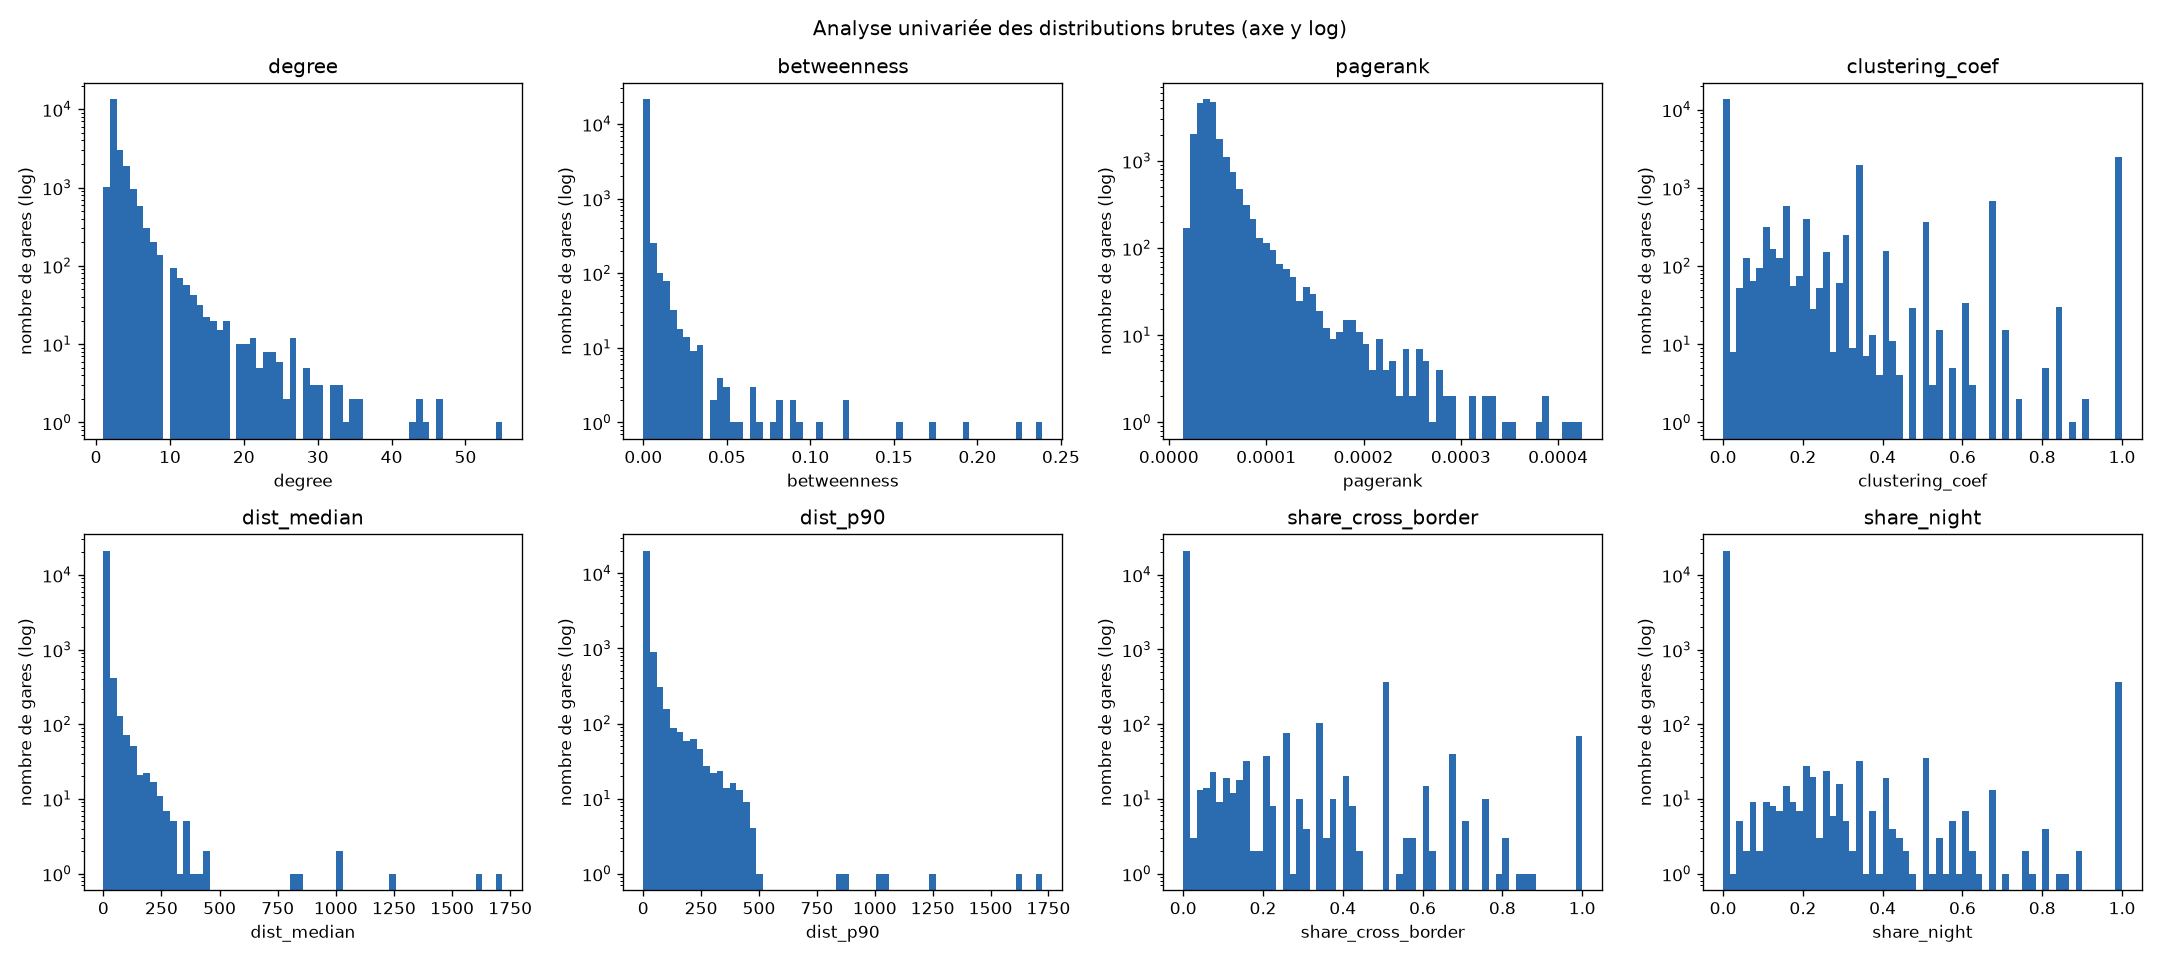

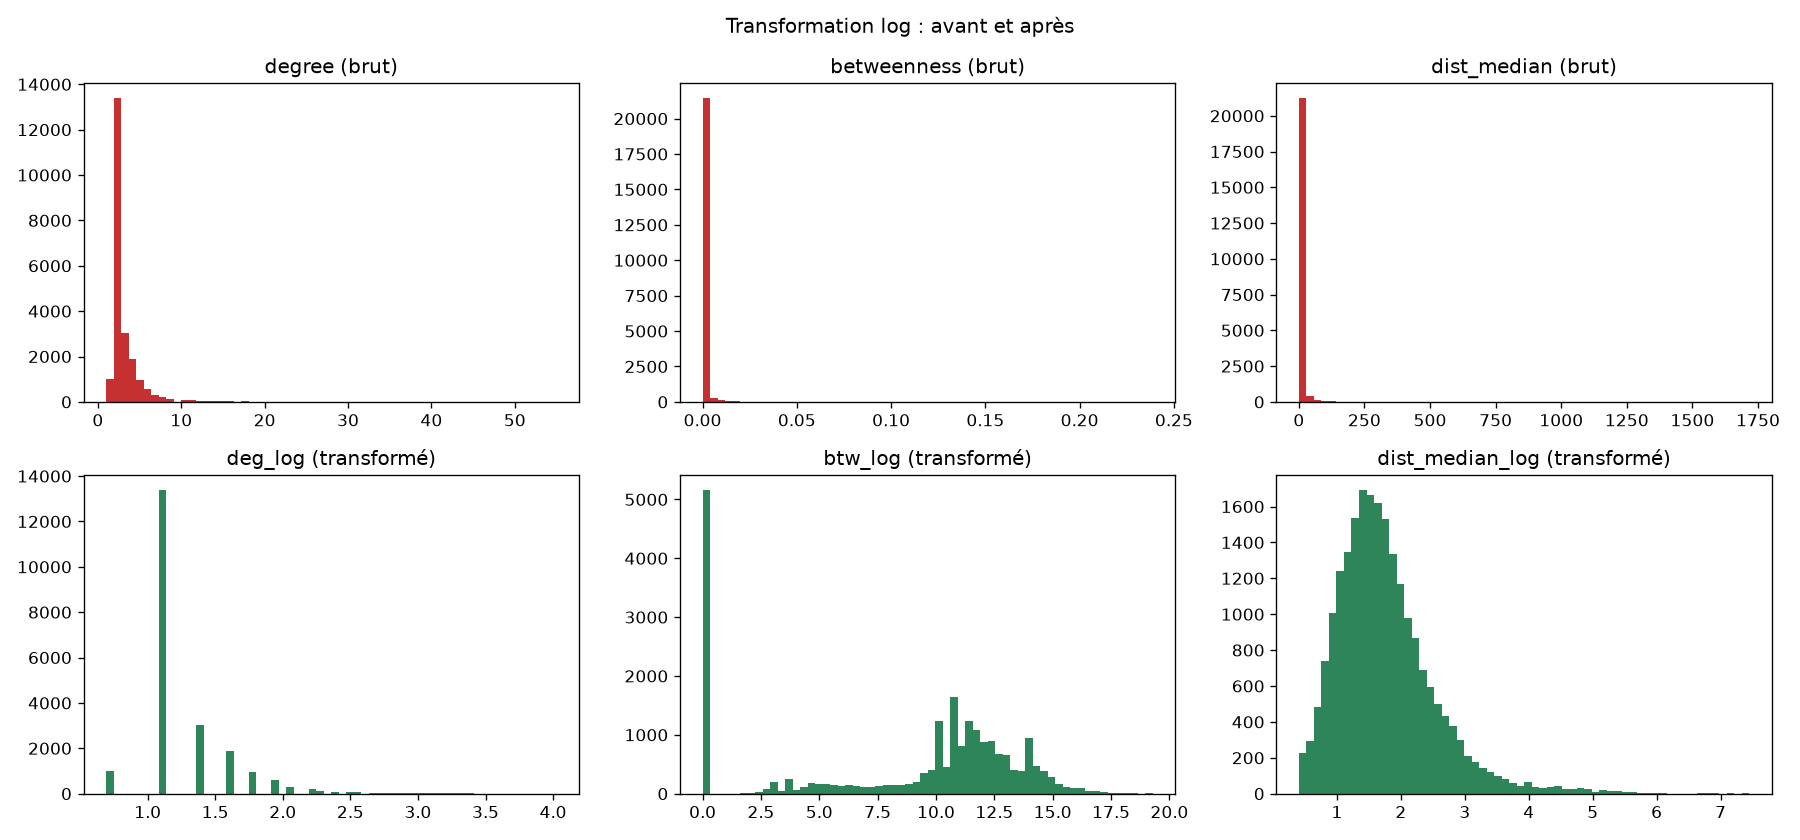

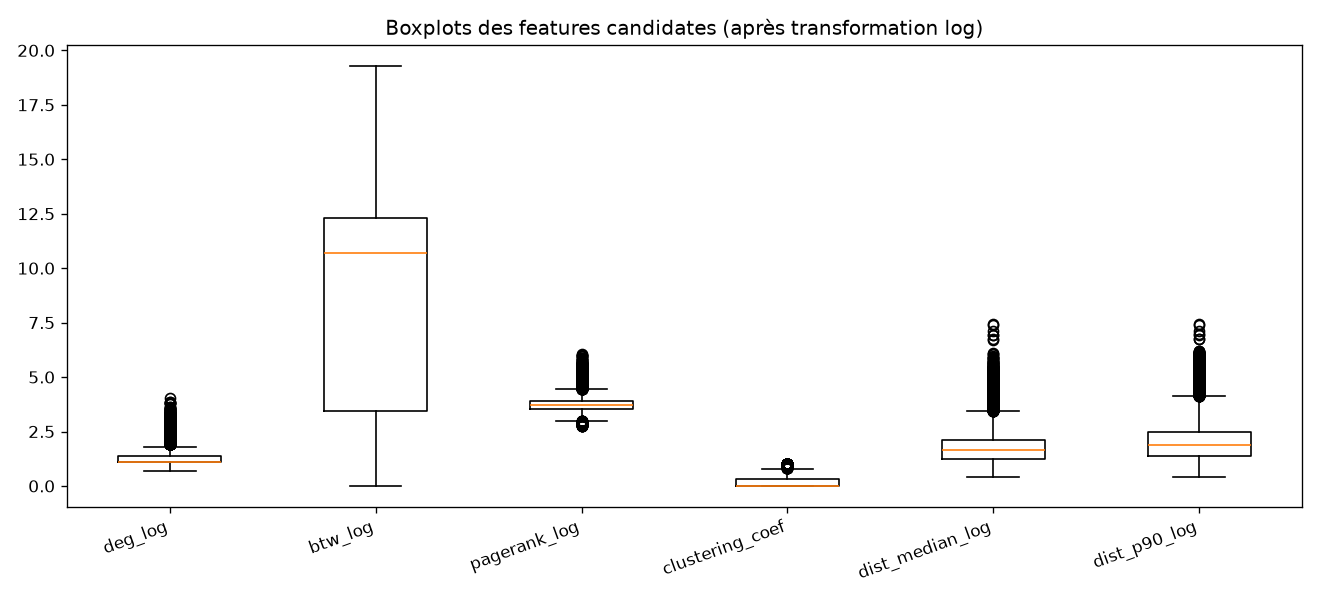

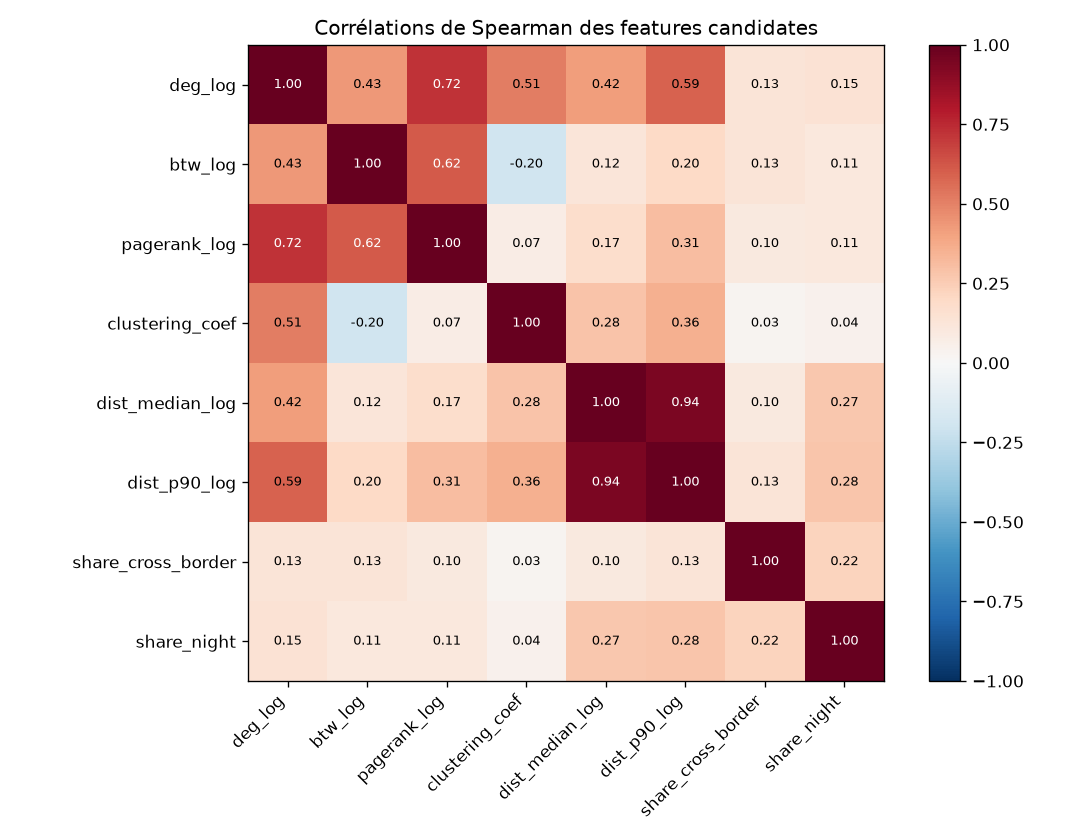

In [12]:
selected = eda_and_select(feats)
display(Image(str(OUT / "eda_distributions.png"), width=950))
display(Image(str(OUT / "eda_transformations.png"), width=850))
display(Image(str(OUT / "eda_boxplots.png"), width=800))
display(Image(str(OUT / "eda_correlation.png"), width=600))

### ACP préalable (avant clustering)

Avant d'appliquer KMeans, on projette les données dans le plan des deux premières
composantes principales pour **vérifier la structure des données** :
- Si des groupes visuels apparaissent ici → le clustering sera robuste.
- Si tout est continu → les frontières seront arbitraires (à mentionner dans les limites).

Le graphique de variance expliquée (scree plot) indique combien d'axes sont nécessaires
pour capturer l'essentiel de l'information (règle du coude ou seuil 80 %).


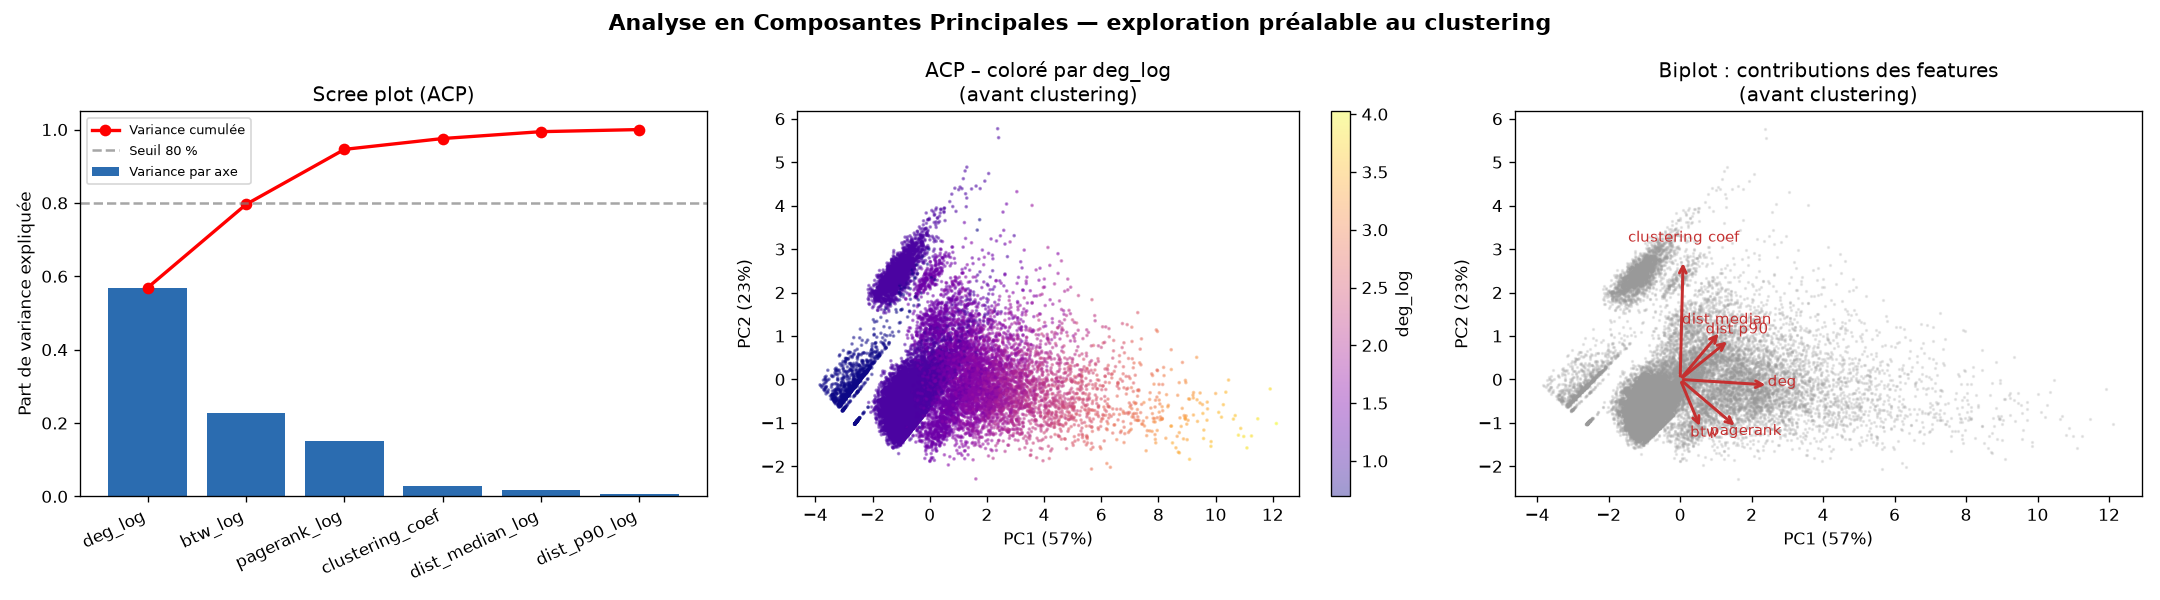

[ACP] variance expliquée par les 2 premiers axes : 79.6%
[ACP] variance expliquée par les 3 premiers axes : 94.6%


In [13]:

# ── ACP préalable : explorer la structure AVANT de choisir k ─────────────────
_X_pca = RobustScaler().fit_transform(feats[selected].to_numpy())
_pca_full = PCA(n_components=len(selected), random_state=SEED).fit(_X_pca)
_pca2     = PCA(n_components=2, random_state=SEED).fit_transform(_X_pca)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Scree plot —
axes[0].bar(range(1, len(selected) + 1), _pca_full.explained_variance_ratio_,
            color="#2b6cb0", label="Variance par axe")
axes[0].plot(range(1, len(selected) + 1),
             np.cumsum(_pca_full.explained_variance_ratio_),
             "o-r", lw=2, label="Variance cumulée")
axes[0].axhline(0.80, ls="--", color="gray", alpha=0.7, label="Seuil 80 %")
axes[0].set_xticks(range(1, len(selected) + 1), selected, rotation=25, ha="right")
axes[0].set_ylabel("Part de variance expliquée"); axes[0].set_title("Scree plot (ACP)")
axes[0].legend(fontsize=8)

# — Projection 2D colorée par deg_log (proxy du degré) —
sc = axes[1].scatter(_pca2[:, 0], _pca2[:, 1],
                     c=feats["deg_log"], cmap="plasma", s=1.5, alpha=0.4)
fig.colorbar(sc, ax=axes[1], label="deg_log")
axes[1].set_xlabel(f"PC1 ({_pca_full.explained_variance_ratio_[0]:.0%})")
axes[1].set_ylabel(f"PC2 ({_pca_full.explained_variance_ratio_[1]:.0%})")
axes[1].set_title("ACP – coloré par deg_log\n(avant clustering)")

# — Biplot : contributions des features —
_load = _pca_full.components_[:2].T
_scale = 3.5
_feat_labels = [f.replace("_log", "").replace("_", " ") for f in selected]
axes[2].scatter(_pca2[:, 0], _pca2[:, 1], s=1, alpha=0.2, color="#999")
for i, fl in enumerate(_feat_labels):
    axes[2].annotate("", xy=(_load[i, 0] * _scale, _load[i, 1] * _scale),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="#c53030", lw=1.8))
    axes[2].text(_load[i, 0] * _scale * 1.15, _load[i, 1] * _scale * 1.15,
                 fl, fontsize=9, color="#c53030", ha="center")
axes[2].set_xlabel(f"PC1 ({_pca_full.explained_variance_ratio_[0]:.0%})")
axes[2].set_ylabel(f"PC2 ({_pca_full.explained_variance_ratio_[1]:.0%})")
axes[2].set_title("Biplot : contributions des features\n(avant clustering)")

fig.suptitle("Analyse en Composantes Principales — exploration préalable au clustering",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "pca_avant_clustering.png", dpi=120)
plt.close(fig)
display(Image(str(OUT / "pca_avant_clustering.png"), width=1000))

_var2 = _pca_full.explained_variance_ratio_[:2].sum()
print(f"[ACP] variance expliquée par les 2 premiers axes : {_var2:.1%}")
print(f"[ACP] variance expliquée par les 3 premiers axes : "
      f"{_pca_full.explained_variance_ratio_[:3].sum():.1%}")


## 4. Clustering

- **KMeans** (modèle principal) : k de 2 à 9, choix par silhouette et coude ;
- **GMM** (challenger) : le BIC baisse jusqu'à k=8 car il sur-découpe des features
  log non gaussiennes, donc peu pertinent face au choix métier ;
- **HDBSCAN** (challenger) : robustesse, et gares atypiques classées en « bruit ».

**Choix de k** : la silhouette est maximale à k=3 (0,454), structure la plus robuste, mais
trop grossière pour l'usage métier. À **k=5** (silhouette 0,400) la partition raffine k=3
et tous les clusters sont nommables : c'est le k retenu (PDF p.24, les sorties doivent être
des familles actionnables).

La part de variance après mise à l'échelle est connue (degré 31 %, clustering local 18 %,
pagerank 16 %, distances 28 %, betweenness 7 %) : la domination du degré est assumée.

[scaling] part de variance post-scaling : {'deg_log': 0.3134, 'btw_log': 0.066, 'pagerank_log': 0.1623, 'clustering_coef': 0.1799, 'dist_median_log': 0.1397, 'dist_p90_log': 0.1386}
[kmeans] k=2 silhouette=0.436 inertie=75264 BIC_GMM=189310
[kmeans] k=3 silhouette=0.456 inertie=53491 BIC_GMM=-27792
[kmeans] k=4 silhouette=0.428 inertie=42917 BIC_GMM=-59997
[kmeans] k=5 silhouette=0.397 inertie=36729 BIC_GMM=-63294
[kmeans] k=6 silhouette=0.346 inertie=32483 BIC_GMM=-73178
[kmeans] k=7 silhouette=0.326 inertie=29006 BIC_GMM=-206078
[kmeans] k=8 silhouette=0.322 inertie=25724 BIC_GMM=-267483
[kmeans] k=9 silhouette=0.317 inertie=24053 BIC_GMM=-265348
[kmeans] k retenu = 5 (silhouette max à k=3)
[modeles] comparaison : {"kmeans": {"n_clusters": 5, "silhouette": 0.397, "pct_bruit": 0.0, "ari_vs_kmeans": 1.0}, "gmm": {"n_clusters": 5, "silhouette": 0.37, "pct_bruit": 0.0, "ari_vs_kmeans": 0.676}, "hdbscan": {"n_clusters": 7, "silhouette": 0.28, "pct_bruit": 0.061, "ari_vs_kmeans": 0.611}}
[

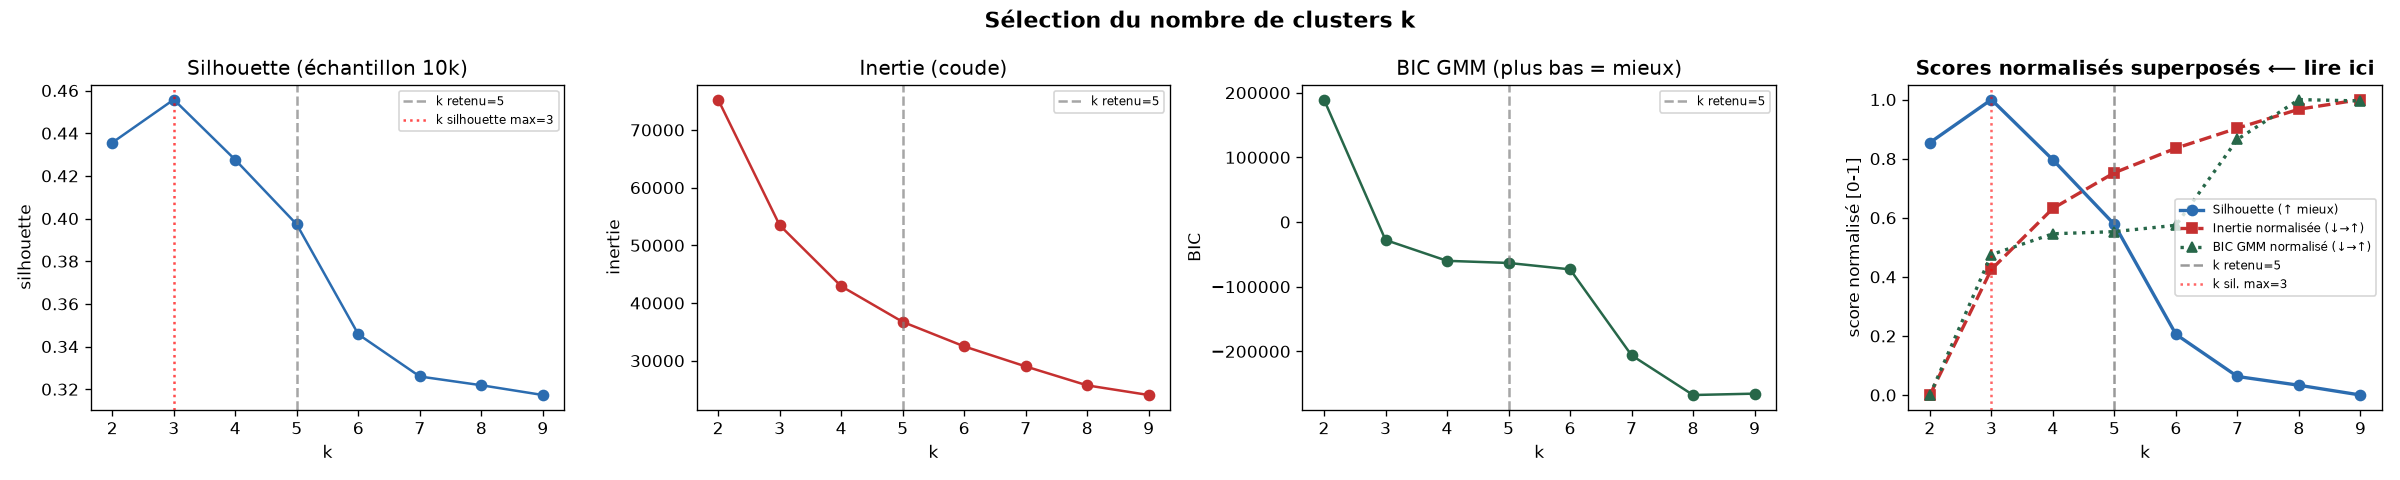

,n_clusters,silhouette,pct_bruit,ari_vs_kmeans
kmeans,5.0,0.397,0.000,1.000
gmm,5.0,0.370,0.000,0.676
hdbscan,7.0,0.280,0.061,0.611


In [14]:
feats, scaler, km, X, metrics = run_clustering(feats, selected, None)
display(Image(str(OUT / "kmeans_selection.png"), width=950))
pd.DataFrame(metrics["model_comparison"]).T

L'accord entre modèles est **modéré** (ARI 0,61 pour HDBSCAN hors bruit, 0,68 pour le GMM) :
d'accord sur les gares contournées et les hubs, en désaccord sur la frontière urbain/corridor,
ce qui colle au caractère continu de cette frontière (cf. §6).

## 5. Validation : stabilité et scénarios de préparation

La validation croisée k-fold (consigne p.7) suppose une cible ; en clustering, on la remplace
par l'**analyse de stabilité** (changement de seed et ré-échantillonnage). On déroule aussi
les **scénarios de préparation** de la p.43. Piège : les scénarios dégénérés ont une
*meilleure* silhouette (un gros cluster plus des micro-clusters d'outliers est trivialement
bien séparé), donc le vrai critère est la dégénérescence des tailles de clusters.

In [15]:
metrics["stability"] = stability_analysis(X, feats["cluster"].to_numpy(), metrics["k_best"])
metrics["ablation"] = ablation(feats, selected, metrics["k_best"])
pd.DataFrame(metrics["ablation"]).T

[stabilite] {'ari_multiseed_mean': 0.996, 'ari_multiseed_min': 0.99, 'ari_bootstrap80_mean': 0.984, 'ari_bootstrap80_min': 0.936, 'n_runs': {'multiseed': 10, 'bootstrap': 20}}
[ablation] raw (sans log ni scaler): silhouette=0.821 tailles=[20475, 1079, 316, 102, 7] [DEGENERE]
[ablation] prepa1a : sans log + RobustScaler: silhouette=0.893 tailles=[21438, 284, 230, 22, 5] [DEGENERE]
[ablation] prepa1b : log + StandardScaler: silhouette=0.358 tailles=[9153, 5086, 3525, 2845, 1370]
[ablation] prepa2 (retenu) : log + RobustScaler: silhouette=0.397 tailles=[11084, 4581, 2880, 2213, 1221]
[ablation] prepa2 sans pagerank: silhouette=0.361 tailles=[9166, 4509, 4087, 2803, 1414]


,silhouette,tailles_clusters,degenere
raw (sans log ni scaler),0.821,"[20475, 1079, 316, 102, 7]",True
prepa1a : sans log + RobustScaler,0.893,"[21438, 284, 230, 22, 5]",True
prepa1b : log + StandardScaler,0.358,"[9153, 5086, 3525, 2845, 1370]",False
prepa2 (retenu) : log + RobustScaler,0.397,"[11084, 4581, 2880, 2213, 1221]",False
prepa2 sans pagerank,0.361,"[9166, 4509, 4087, 2803, 1414]",False


## 6. Interprétation des clusters

| Cluster | Nom | Lecture | Silhouette |
|---|---|---|---|
| 0 (n=1 221) | **Hub structurant / porte nocturne** | degree +2,39σ, dist_p90 +1,15σ : gares très connectées avec liaisons longues | — |
| 1 (n=11 084) | **Nœud régional maillé** | tout proche de 0 : la gare européenne typique, groupe le plus large | — |
| 2 (n=4 581) | **Gare contournée par les directs** | clustering_coef +0,91σ : voisinage dense, les voisins se parlent entre eux sans passer par elle | — |
| 3 (n=2 880) | **Maillon urbain/périurbain** | clustering_coef +3,03σ (valeur max de la grille) : micro-réseau local extrêmement dense, type S-Bahn / RER | — |
| 4 (n=2 213) | **Gare de corridor interurbain** | dist_median +0,28σ, dist_p90 +0,24σ : arrêts espacés sur un axe longue distance | — |

Honnêtement, la frontière maillon/corridor (clusters 3 et 4) découpe un **gradient continu**
d'espacement des arrêts plus que deux populations distinctes : deux segments utiles d'un même
axe. Les « gares connues » (fort degré) sont les moins typiques de leur cluster ; les exemples
représentatifs sont proches du centroïde.



=== PROFILS DES CLUSTERS (médianes) ===
             n  degree  betweenness  clustering_coef  dist_median  dist_p90  share_cross_border  share_night  pct_gares_nuit  pct_in_giant                               nom
cluster                                                                                                                                                                     
0         1221     8.0       0.0014           0.1429      17.0560   54.1706                 0.0          0.0          0.2482        0.9697  Hub structurant / porte nocturne
1        11084     2.0       0.0000           0.0000       2.8258    3.3530                 0.0          0.0          0.0014        0.9262              Nœud régional maillé
2         4581     4.0       0.0001           0.3000       5.9040   10.9458                 0.0          0.0          0.0140        0.9642   Gare contournée par les directs
3         2880     2.0       0.0000           1.0000       4.2760    5.5160                 0.

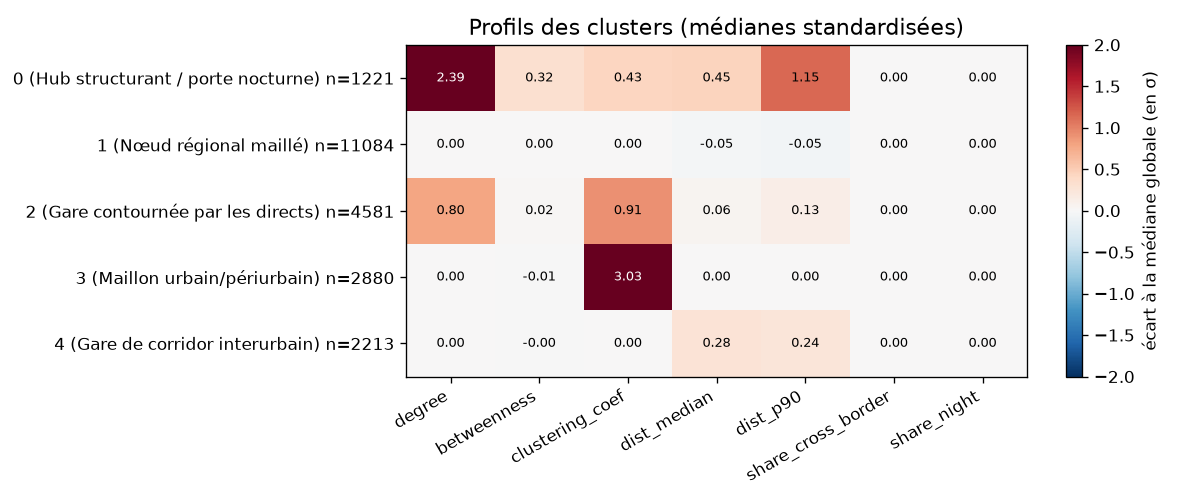

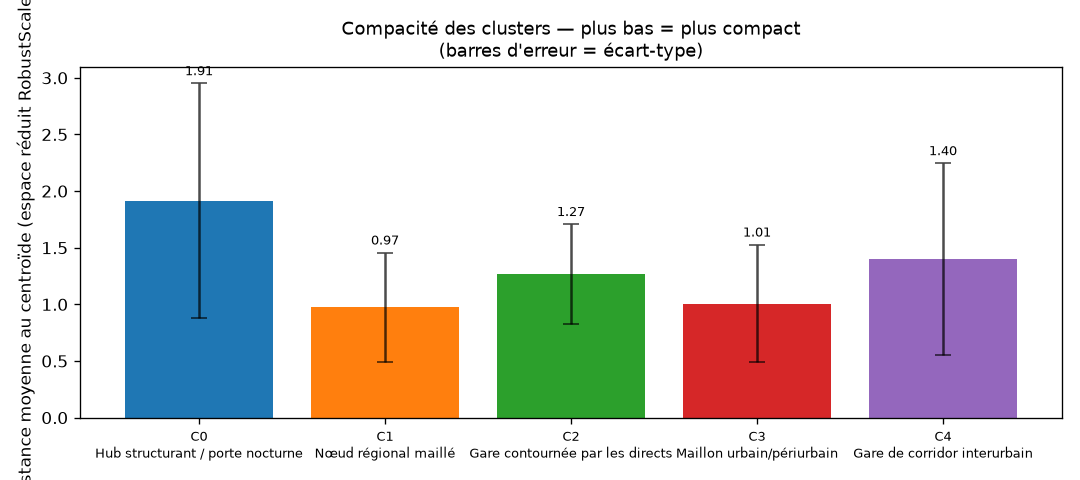

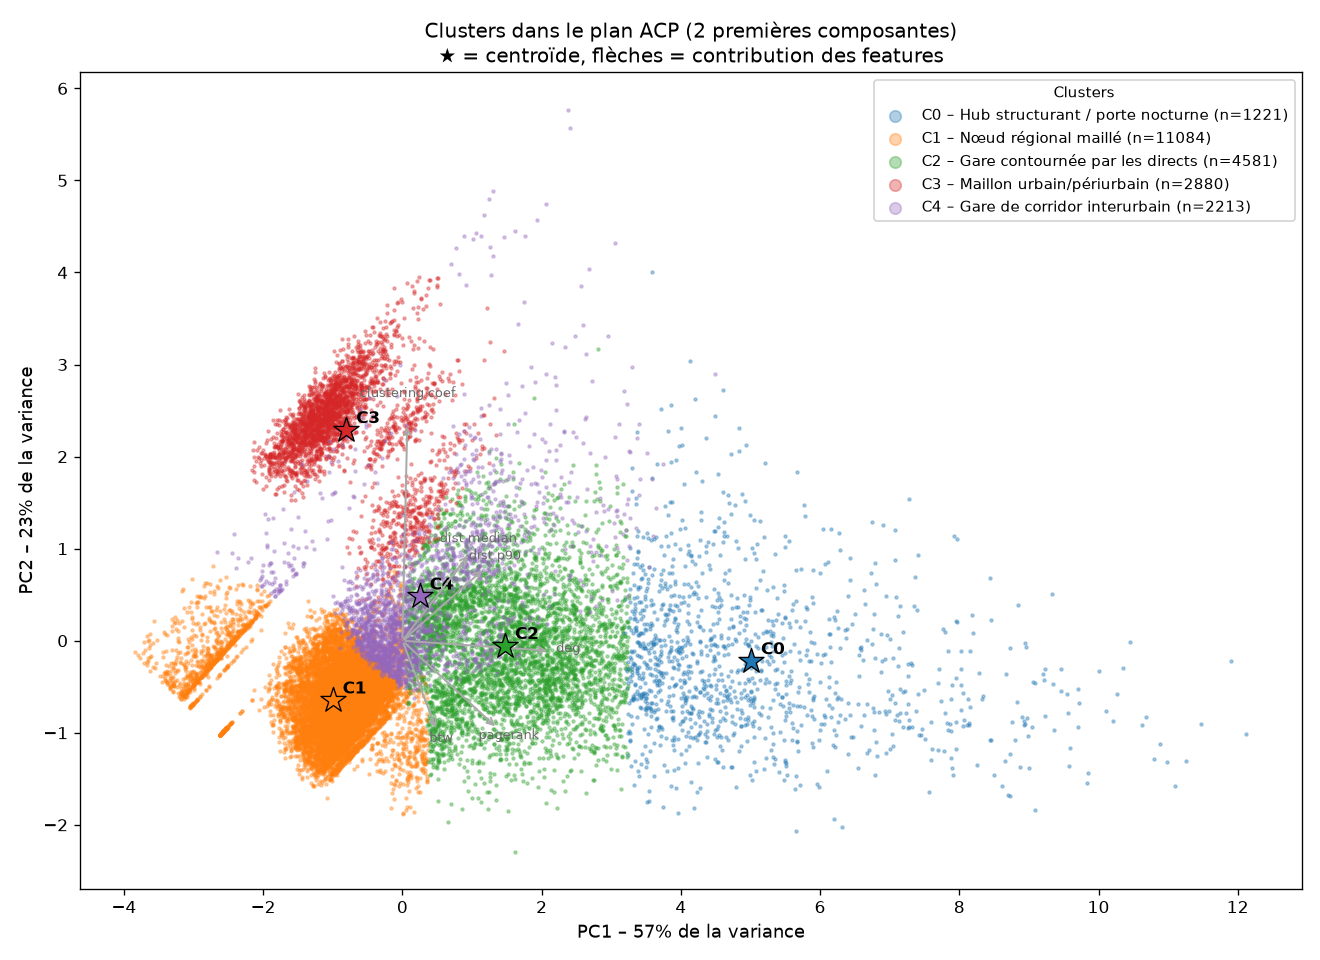

In [16]:
prof = interpret(feats, selected, metrics)
display(Image(str(OUT / "cluster_profiles.png"), width=900))
display(Image(str(OUT / "compacite_clusters.png"), width=750))
display(Image(str(OUT / "clusters_pca.png"), width=900))


### Contrôle du biais de couverture GTFS

Risque identifié dès l'exploration : la couverture des feeds GTFS est très inégale (DE ≫ IT,
pas de feed de jour NL/DK/GR/UA/RO…). On vérifie que les clusters ne sont pas de simples
proxys de pays (composition normalisée par la taille du cluster, colonne AUTRES incluse).

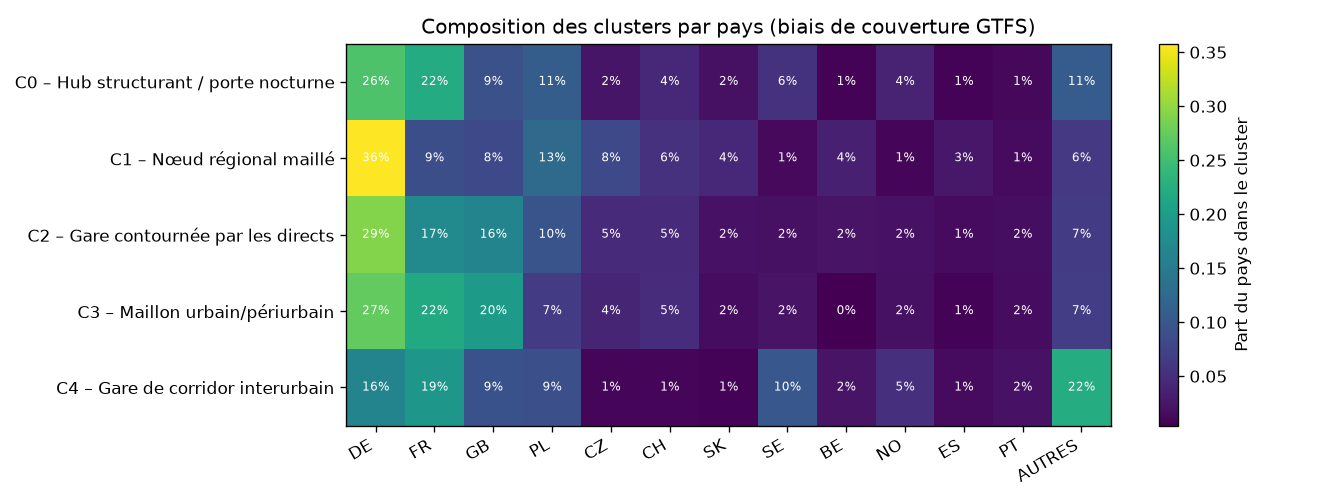

,DE,FR,GB,PL,CZ,CH,SK,SE,BE,NO,ES,PT,AUTRES
cluster,,,,,,,,,,,,,
0,317,271,113,132,30,53,25,69,9,47,9,15,131
1,3968,988,915,1408,916,613,484,141,392,108,294,166,691
2,1341,790,752,439,211,210,96,89,104,97,64,79,309
3,787,632,568,192,117,142,44,66,12,57,23,44,196
4,363,425,205,200,23,23,16,221,49,114,33,48,493


In [17]:
display(Image(str(OUT / "cluster_x_pays.png"), width=900))
pd.read_csv(OUT / "cluster_x_pays.csv", index_col=0)

### Les portes nocturnes

Définition : gare reliée **aux deux réseaux** (0 < `share_night` < 1). Les 366 gares à
`share_night` = 1 (BG, RO, UA, TR…) tirent toute leur connectivité de Back on Track : ce sont
des pays **sans feed GTFS de jour**, un trou de couverture listé à part
(`gares_nuit_sans_reseau_jour.csv`), pas des portes nocturnes.

Le top obtenu **valide le clustering de l'extérieur** : il est dominé par le système ÖBB
Nightjet et ses correspondances (Wien Hbf, Linz, Villach, Innsbruck, Zagreb, Budapest,
Kraków, Bratislava, Bologna Centrale, Ljubljana), toutes classées « Hub structurant », alors
qu'aucune information nocturne n'a servi à l'entraînement.

In [18]:
pd.read_csv(OUT / "portes_nocturnes_top30.csv").head(15)

,station_name,city,country_geo,cluster,degree,share_night,betweenness,score_porte
0,Zagreb Glavni kolodvor,Zagreb Glavni kolodvor,HR,0,9,0.888889,0.000599,2.046742
1,Budapest-Kelenföld,Budapest-Kelenföld,HU,0,9,0.888889,0.003281,2.046742
2,Krakow Glowny,Krakow Glowny,PL,0,13,0.769231,0.014207,2.030044
3,Bologna Centrale,Bologna Centrale,IT,0,10,0.800000,0.006526,1.918316
4,Chop,Chop,UA,0,7,0.857143,0.002005,1.782378
5,Katowice,Katowice,PL,0,21,0.571429,0.016874,1.766310
6,Linz Hbf (AT),Linz Hbf,AT,0,14,0.642857,0.013463,1.740889
7,Bratislava hl.st.,Bratislava hl.st.,SK,0,12,0.666667,0.012613,1.709966
8,Wien HBF (AT),Wien HBF,AT,0,18,0.555556,0.020608,1.635799
9,Villach Hbf,Villach Hbf,AT,0,13,0.615385,0.014492,1.624035


## 7. Carte et sauvegarde du modèle

Carte interactive : [`output/map_clusters.html`](output/map_clusters.html) (folium).
Le modèle (scaler + KMeans + liste des features) est sérialisé en joblib (consigne PDF p.42) ;
le script d'inférence séparé est [`inference.py`](inference.py) :
`python clustering/inference.py --name "Wien"`.

[geonames] 33896 villes
[map] carte folium : 10811 gares affichées


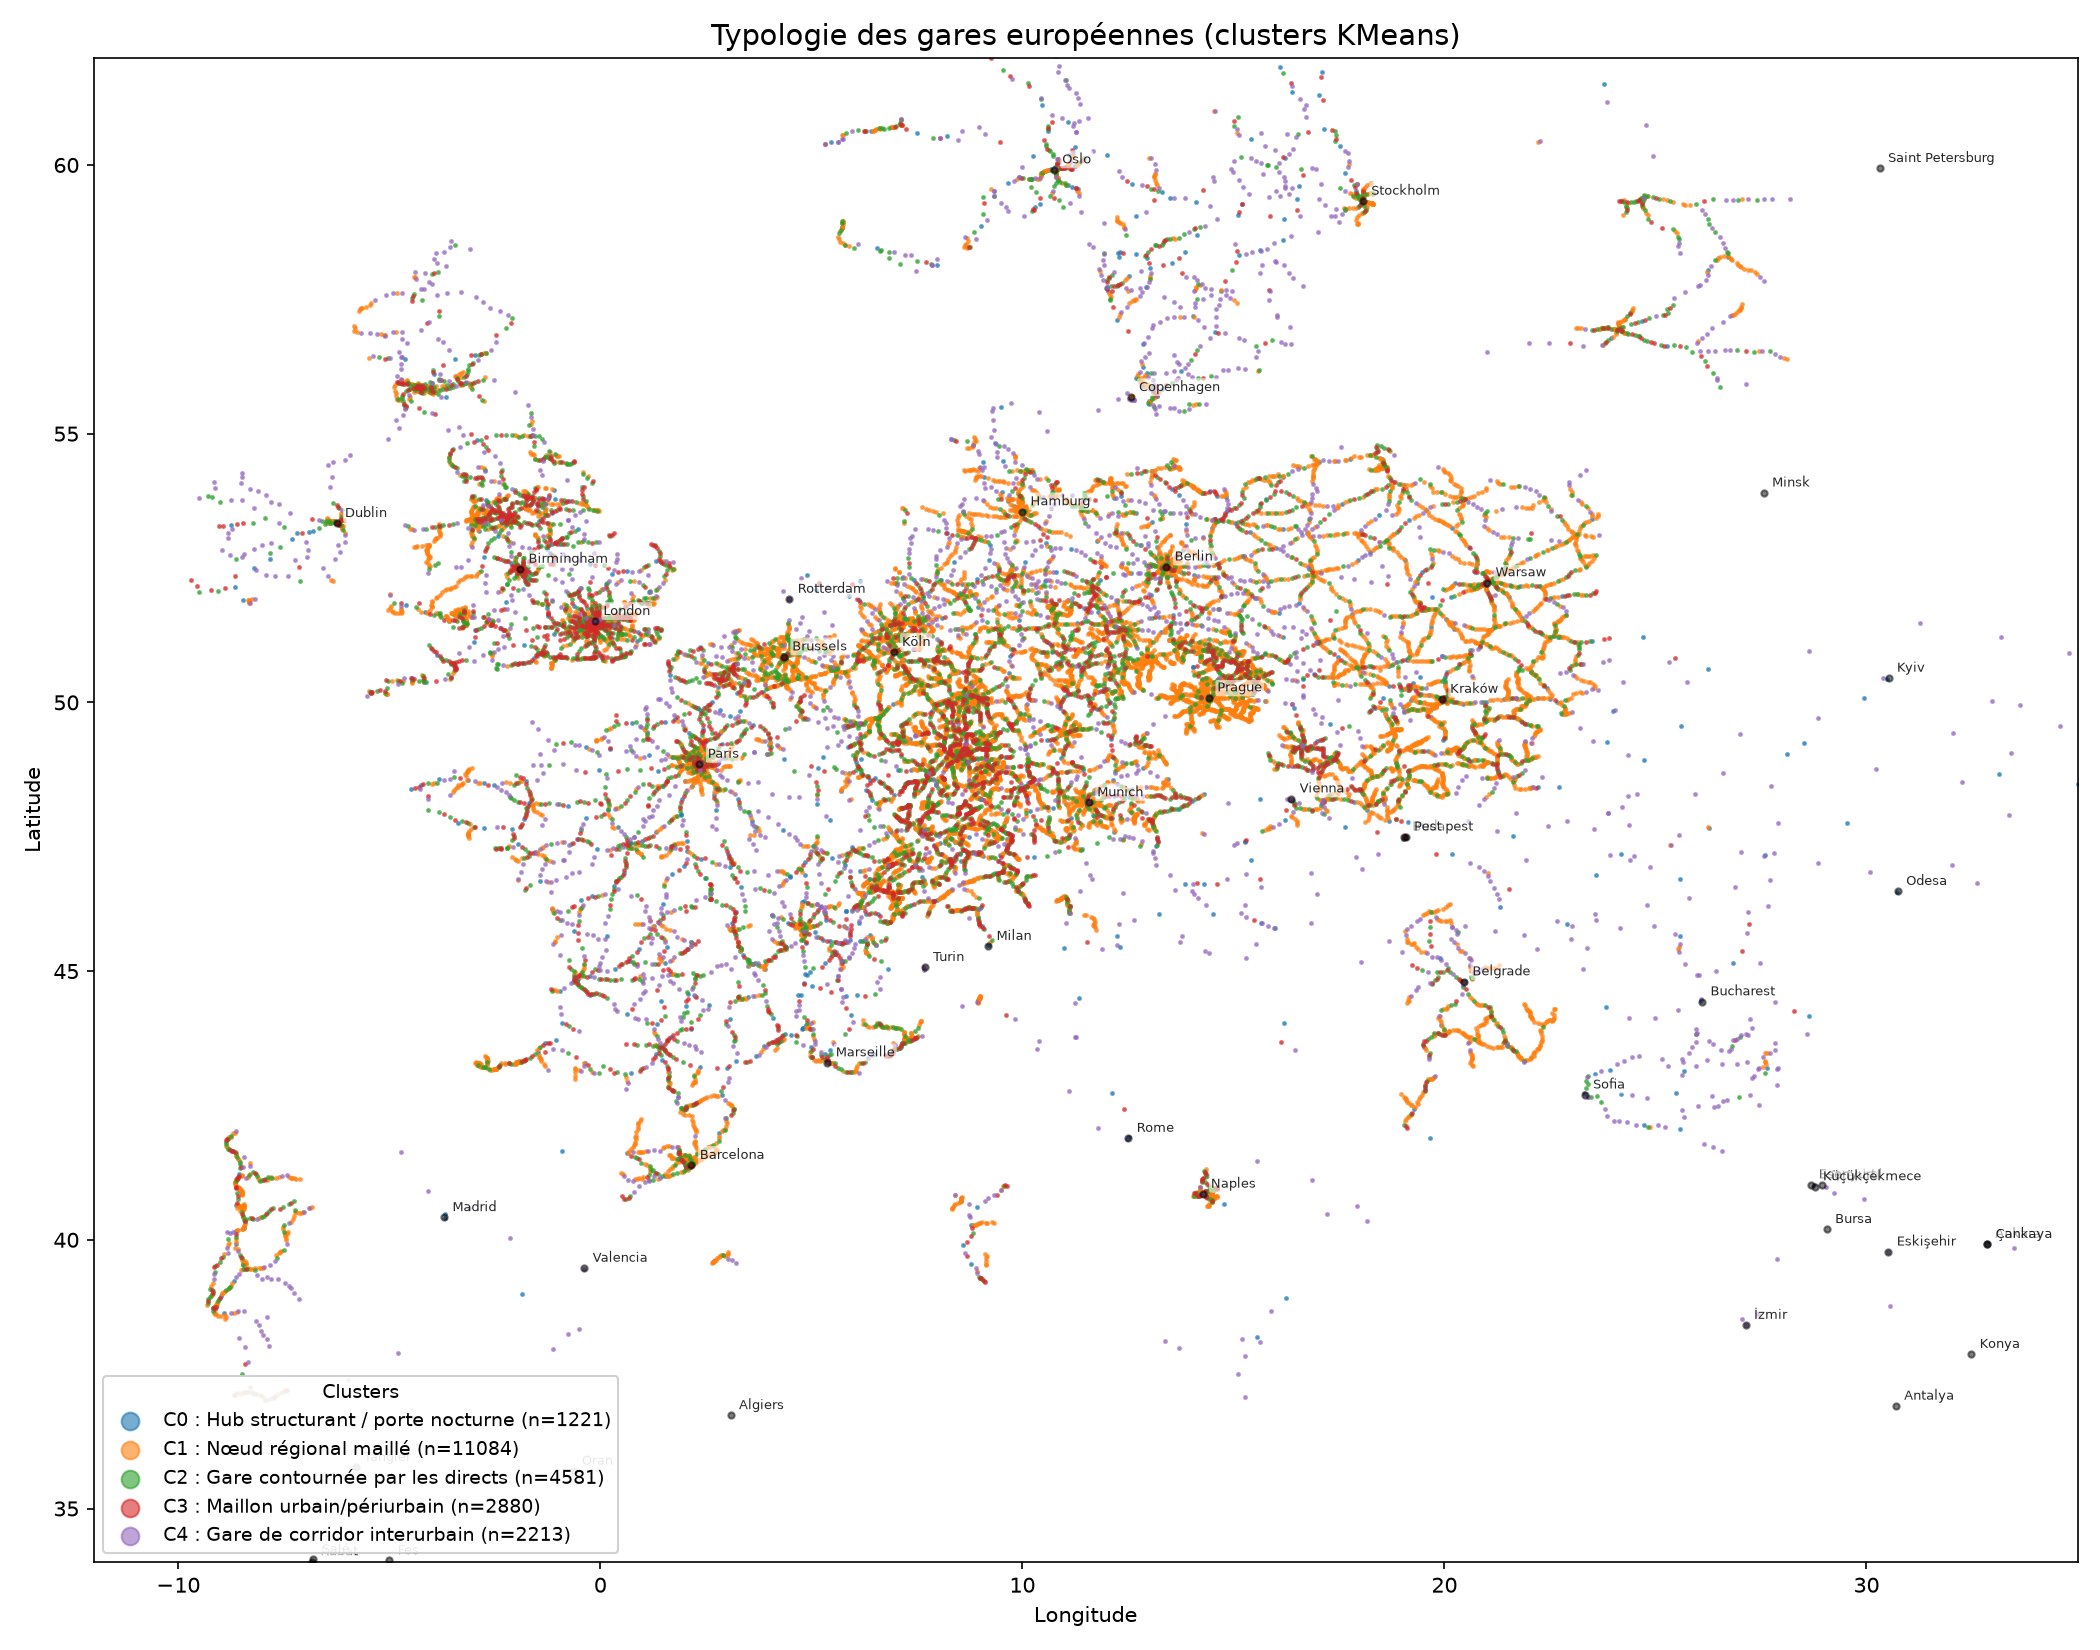

In [19]:
import joblib

# Chargement des villes GeoNames pour les annoter sur la carte (cache local)
_cities_map = load_geonames_cities()

make_maps(feats, skip_folium=False, cities_df=_cities_map)
feats[["station_id", "station_name", "city", "country_geo", "lat", "lon",
       "degree", "betweenness", "clustering_coef", "dist_median", "dist_p90",
       "share_cross_border", "share_night", "cluster", "cluster_gmm",
       "cluster_hdbscan"]].to_csv(OUT / "gares_clusters.csv", index=False)
joblib.dump({"scaler": scaler, "kmeans": km, "features": selected,
             "cluster_names": CLUSTER_NAMES, "seed": 42},
            OUT / "model_typologie_gares.joblib")
display(Image(str(OUT / "map_clusters.png"), width=1000))


### Démonstration d'inférence (modèle entraîné)

Réutilisation du modèle `km` + `scaler` en mémoire sur quelques gares. Pour l'inférence en production à partir du modèle sauvegardé, voir le script séparé [`inference.py`](inference.py) (`python clustering/inference.py --name "Wien"`).

In [20]:
demo = feats[feats["station_name"].str.contains(
    "Wien Hbf|Zürich HB|Gatley|Chamarande|Frankfurt .M. Hbf",
    case=False, na=False)]
pred = km.predict(scaler.transform(demo[selected].to_numpy()))
for name, cc, c in zip(demo["station_name"], demo["country_geo"], pred):
    print(f"{name} ({cc}) -> cluster {c} : {CLUSTER_NAMES.get(int(c), '')}")

Chamarande (FR) -> cluster 1 : Nœud régional maillé
Gatley (GB) -> cluster 3 : Maillon urbain/périurbain
Wien Hbf (Autoreisezuganlage) (AT) -> cluster 4 : Gare de corridor interurbain
Wien HBF (AT) (AT) -> cluster 0 : Hub structurant / porte nocturne
Zürich HB (CH) -> cluster 0 : Hub structurant / porte nocturne
Frankfurt (M) Hbf (DE) -> cluster 0 : Hub structurant / porte nocturne


## 8. Enrichissement exogène (population) et sous-desserte

Le sujet recommande d'enrichir les données avec des variables exogènes, la population
en tête (p.23, p.34, p.37). On rattache chaque gare à la ville la plus proche (GeoNames,
villes > 15 000 hab) et on récupère sa population. Deux usages :

1. **Descriptif** : la population de la ville desservie, par cluster, montre que les hubs
   desservent des villes nettement plus grandes que les autres familles.
2. **Score de sous-desserte** (p.24) : au niveau ville, on compare l'offre rail locale
   (somme des degrés des gares dans un rayon de 12 km) à la population, via le résidu
   d'une régression `log(offre) ~ log(population)` **ajustée par pays**. Une ville sous la
   tendance de son pays a moins d'offre rail que sa taille ne le laisse attendre.

Le fit par pays est indispensable : sans lui, le score mesurerait surtout la profondeur des
feeds GTFS (l'Allemagne décrit chaque halte, l'Espagne seulement les grandes gares). On ne
note que les pays à couverture suffisante, et les villes sans gare à moins de 12 km sont
écartées (trou de données, pas sous-desserte).

[geonames] 33896 villes
[enrich] 91.2% des gares rattachées à une ville < 25 km


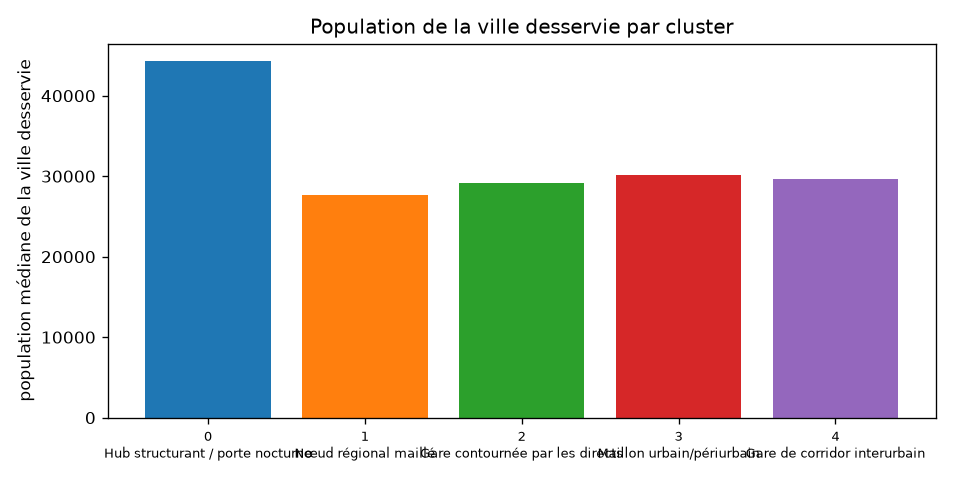

cluster
0    44263.0
1    27685.0
2    29147.0
3    30157.0
4    29622.0
Name: city_pop, dtype: float64

In [21]:
cities = load_geonames_cities()
feats = enrich_population(feats, cities)

# Descriptif : population médiane de la ville desservie, par cluster
popc = feats.groupby("cluster")["city_pop"].median()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"{c}\n{CLUSTER_NAMES.get(c, '')}" for c in popc.index], popc.values,
       color=[plt.get_cmap("tab10")(c % 10) for c in popc.index])
ax.set_ylabel("population médiane de la ville desservie")
ax.set_title("Population de la ville desservie par cluster")
plt.setp(ax.get_xticklabels(), fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "population_par_cluster.png", dpi=120); plt.close(fig)
display(Image(str(OUT / "population_par_cluster.png"), width=650))
popc.round(0)

[sous-desserte] 1018 villes notées dans 10 pays (>= 50k hab) -> sous_desserte_villes.csv


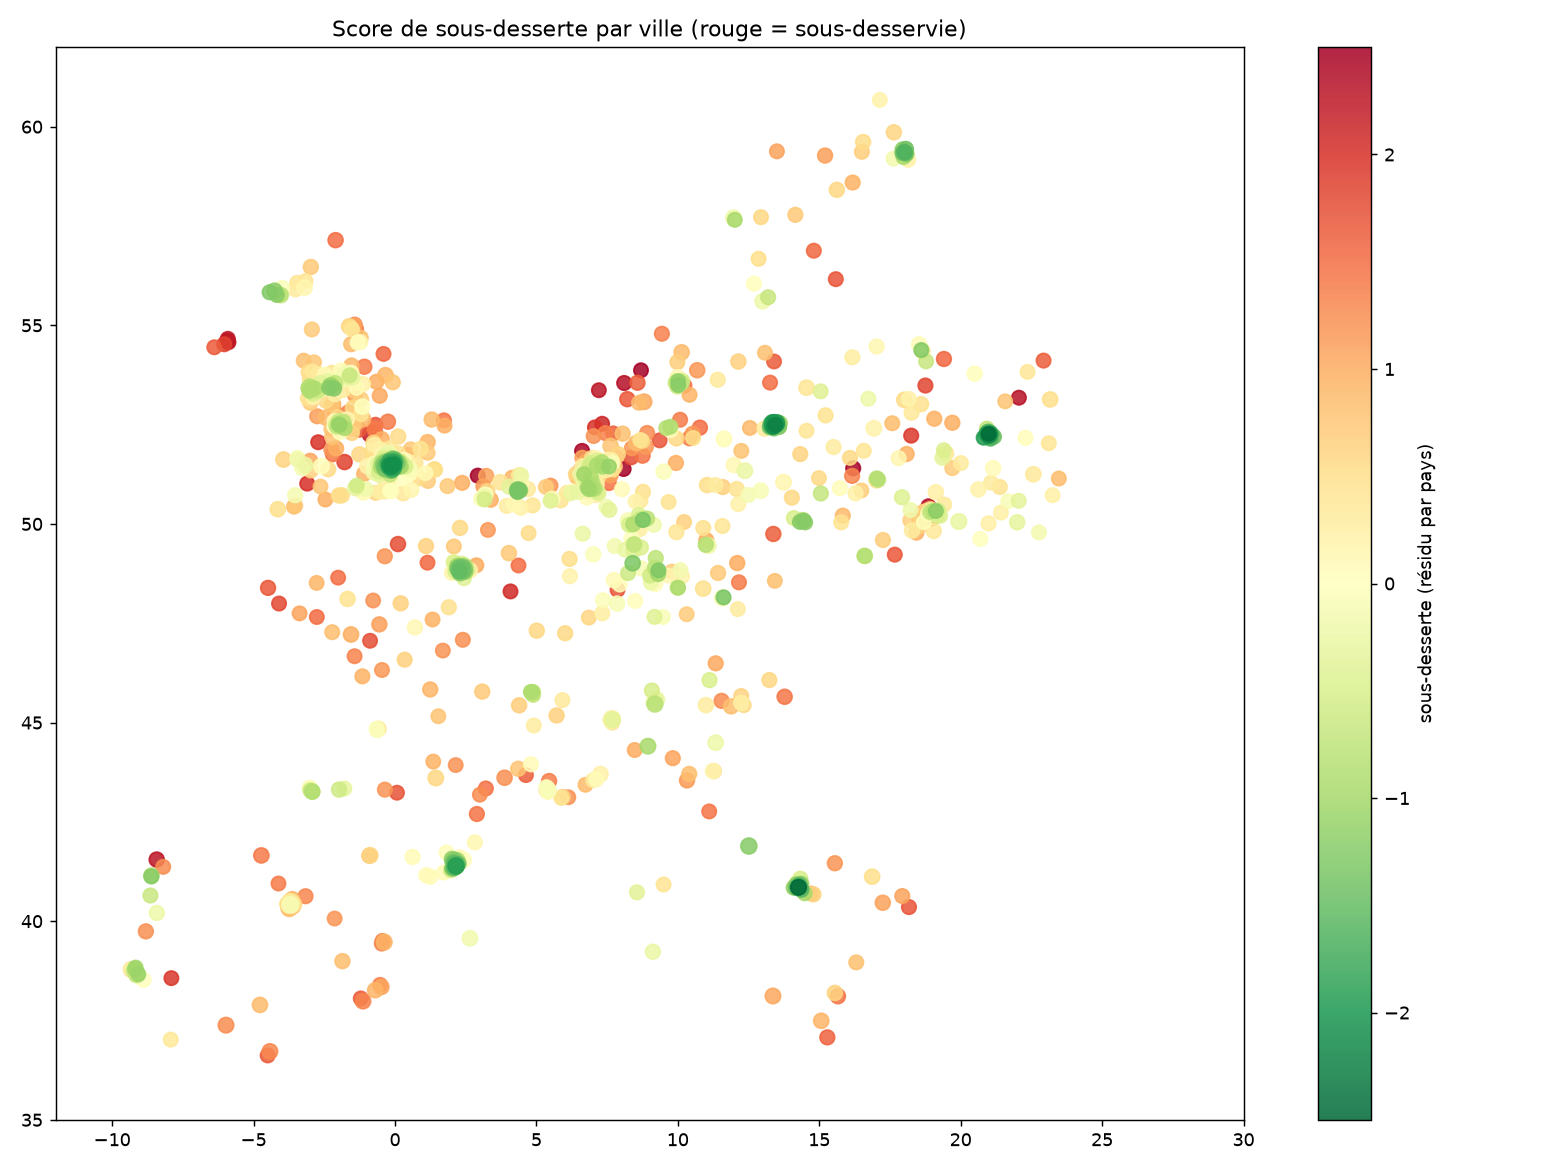

,name,country,population,n_gares,offre,sous_desserte
9,Ostend,BE,69011,1,1,3.10
249,Cuxhaven,DE,52677,1,2,3.03
277,Arnsberg,DE,74879,2,3,2.88
760,Belfast,GB,348005,1,2,2.51
930,Lubin,PL,77532,1,2,2.46
263,Bocholt,DE,73943,3,5,2.44
59,Wilhelmshaven,DE,84393,3,6,2.34
888,Łomża,PL,62019,1,2,2.32
910,Tarnowskie Góry,PL,60938,1,2,2.31
236,Emden,DE,51526,2,5,2.27


In [22]:
villes = sous_desserte_villes(feats, cities)

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(villes["lon"], villes["lat"], c=villes["sous_desserte"],
                cmap="RdYlGn_r", s=18 + villes["pop_log"] * 4, alpha=0.85,
                vmin=-2.5, vmax=2.5)
ax.set_xlim(-12, 30); ax.set_ylim(35, 62)
ax.set_title("Score de sous-desserte par ville (rouge = sous-desservie)")
fig.colorbar(sc, label="sous-desserte (résidu par pays)")
fig.tight_layout(); fig.savefig(OUT / "sous_desserte_map.png", dpi=130); plt.close(fig)
display(Image(str(OUT / "sous_desserte_map.png"), width=850))

villes.head(15)[["name", "country", "population", "n_gares", "offre", "sous_desserte"]].round(2)

In [23]:
# Scénario : ajouter la population comme feature supplémentaire (2nd niveau
# d'enrichissement, p.23 ; scénario à expérimenter, p.43)
pop_feat = np.log1p(feats["city_pop"].fillna(0)).to_numpy()
X_pop = RobustScaler().fit_transform(
    np.column_stack([feats[selected].to_numpy(), pop_feat]))
km_pop = KMeans(n_clusters=metrics["k_best"], n_init=10, random_state=SEED).fit(X_pop)
ari = adjusted_rand_score(feats["cluster"], km_pop.labels_)
sil = silhouette_score(X_pop, km_pop.labels_, sample_size=SIL_SAMPLE, random_state=SEED)
print(f"[scenario reseau+pop] silhouette={sil:.3f} ; ARI vs typologie reseau seule={ari:.3f}")
print("ARI proche de 1 : la population enrichit la typologie sans la redéfinir.")
print("Plus bas : elle crée un découpage sensiblement différent.")

[scenario reseau+pop] silhouette=0.407 ; ARI vs typologie reseau seule=0.734
ARI proche de 1 : la population enrichit la typologie sans la redéfinir.
Plus bas : elle crée un découpage sensiblement différent.


## 9. Conclusions et limites

**Résultats** :
- une typologie en 5 familles nommables, **très stable** (ARI multi-seeds 0,996 ;
  bootstrap 80 % : 0,965), l'équivalent non supervisé de la validation croisée ;
- accord modéré entre modèles (GMM 0,68, HDBSCAN 0,61 hors bruit) : d'accord sur les hubs
  et les gares contournées, en désaccord sur la frontière continue urbain/corridor ;
- les « portes nocturnes » ressortent sans qu'aucune information nocturne n'ait servi au
  clustering (validation externe forte) ;
- le maillage transfrontalier réel ne fait que 2,3 % des tronçons, et le réseau de nuit
  touche 3,2 % des gares.

**Limites assumées** :
1. `dim_route_train` contient des tronçons consécutifs, pas des liaisons origine-destination :
   le degré mesure la diversité d'infrastructure, pas l'offre commerciale ;
2. pas de fréquence de passage en base (trips dédupliqués par l'ETL) : un hub est mesuré en
   diversité de liaisons, pas en nombre de trains ;
3. couverture GTFS inégale selon les pays (pas de feed de jour NL/DK/GR/UA/RO…) : contrôlée
   par la matrice cluster × pays et la liste « nuit seule », mais pas corrigeable sans
   nouvelles sources ;
4. betweenness approximée (1000 pivots, seed fixée) : l'exact sur 22k nœuds est trop lent en
   networkx ;
5. la frontière maillon/corridor découpe un gradient continu (assumé, cf. §6).

**Perspectives** : recalculer une fréquence hebdomadaire par tronçon depuis les feeds GTFS
(calendar.txt) pour enrichir le profil des hubs, et croiser la typologie avec la population
des villes (Eurostat NUTS) pour l'axe sous-desserte.